# Predicting Six-Year Graduation Rates at U.S. Four-Year Colleges
## A Statistical and Machine Learning Analysis of Affordability and Institutional Characteristics

**QM 640 Capstone | Shahid Ahmad**

This Google Colab notebook implements the approved synopsis as one reproducible workflow. It downloads and audits the U.S. Department of Education College Scorecard data, constructs the institution-level analytic sample, answers all four research questions, runs the planned sensitivity and subgroup checks, produces report-ready tables and figures, and exports dashboard-ready results.

### Research questions

1. After adjustment, how are average net price, Pell Grant share, and federal-loan share associated with the pooled six-year graduation rate?
2. Do adjusted graduation rates differ across institutional-control and locale categories?
3. How accurately do linear, regularized, random-forest, and gradient-boosting models predict unseen institutions?
4. Does the affordability block improve prediction beyond organizational and resource characteristics?

### Execution

1. Open this file in Google Colab.
2. Select **Runtime > Run all**. A CPU runtime is sufficient.
3. The notebook first tries the official June 10, 2026 download. If the agency changes the endpoint, it prompts you to upload the current institution-level ZIP or CSV.
4. At the end, download `QM640_capstone_outputs.zip`.

The untouched test set is used once for final performance reporting. Statistical associations, model importance, scenario comparisons, and residuals are not interpreted as causal effects or institutional rankings.

## 1. Environment and reproducibility settings

The next cells install only missing packages, import the analysis libraries, create the project folders, fix the random seed, and record package versions. `QUICK_RUN=False` executes the full planned tuning grids. Change it to `True` only for a short code check; do not use quick-run results in the final report.

In [1]:
import importlib.util
import subprocess
import sys

packages = {
    "numpy": "numpy>=1.24",
    "pandas": "pandas>=2.0",
    "scipy": "scipy>=1.10",
    "sklearn": "scikit-learn>=1.3",
    "statsmodels": "statsmodels>=0.14",
    "matplotlib": "matplotlib>=3.7",
    "seaborn": "seaborn>=0.12",
    "openpyxl": "openpyxl>=3.1",
    "requests": "requests>=2.31",
    "bs4": "beautifulsoup4>=4.12",
    "ipywidgets": "ipywidgets>=8.0",
    "joblib": "joblib>=1.3",
    "IPython": "ipython>=8.0",}
missing = [spec for module, spec in packages.items() if importlib.util.find_spec(module) is None]
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])
print("Environment ready.")


Environment ready.


In [2]:
from __future__ import annotations

import hashlib
import json
import math
import os
import platform
import random
import re
import shutil
import time
import warnings
import zipfile
from pathlib import Path

import IPython
import bs4
import ipywidgets
import joblib
import matplotlib.pyplot as plt
import numpy as np
import openpyxl
import pandas as pd
import requests
import scipy
import seaborn as sns
import sklearn
import statsmodels.api as sm
import statsmodels.formula.api as smf
from bs4 import BeautifulSoup
from IPython.display import HTML, Markdown, display
from patsy import build_design_matrices
from scipy import stats
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.inspection import PartialDependenceDisplay, permutation_importance
from sklearn.linear_model import ElasticNet, LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import (
    GridSearchCV,
    KFold,
    StratifiedKFold,
    cross_validate,
    train_test_split,)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, RobustScaler
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.multitest import multipletests
from statsmodels.stats.outliers_influence import variance_inflation_factor

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)
sns.set_theme(style="whitegrid", context="notebook")

RANDOM_STATE = 640
TEST_SIZE = 0.20
CV_FOLDS = 5
ALPHA = 0.05
MIN_ANALYTIC_N = 368
MIN_TEST_N_RQ3 = 124
MIN_SUBGROUP_N = 20
N_JOBS = -1
QUICK_RUN = False

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

ROOT = Path.cwd()
RAW_DIR = ROOT / "data" / "raw"
PROCESSED_DIR = ROOT / "data" / "processed"
TABLE_DIR = ROOT / "reports" / "tables"
FIGURE_DIR = ROOT / "reports" / "figures"
MODEL_DIR = ROOT / "models"
for folder in [RAW_DIR, PROCESSED_DIR, TABLE_DIR, FIGURE_DIR, MODEL_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

def save_table(frame: pd.DataFrame, filename: str, index: bool = False) -> Path:
    path = TABLE_DIR / filename
    frame.to_csv(path, index=index)
    return path

def save_figure(filename: str) -> Path:
    path = FIGURE_DIR / filename
    plt.savefig(path, dpi=220, bbox_inches="tight")
    return path

def sha256_file(path: Path, chunk_size: int = 1024 * 1024) -> str:
    digest = hashlib.sha256()
    with path.open("rb") as handle:
        for chunk in iter(lambda: handle.read(chunk_size), b""):
            digest.update(chunk)
    return digest.hexdigest()

versions = pd.DataFrame({"component": ["Python", "Platform", "numpy", "pandas", "scipy", "scikit-learn", "statsmodels", "matplotlib", "seaborn", "requests", "beautifulsoup4", "openpyxl", "ipywidgets", "IPython", "joblib"], "version": [platform.python_version(), platform.platform(), np.__version__, pd.__version__, scipy.__version__, sklearn.__version__, sm.__version__, plt.matplotlib.__version__, sns.__version__, requests.__version__, bs4.__version__, openpyxl.__version__, ipywidgets.__version__, IPython.__version__, joblib.__version__]})
save_table(versions, "00_environment_versions.csv")
(ROOT / "requirements_locked.txt").write_text("\n".join([f"numpy=={np.__version__}", f"pandas=={pd.__version__}", f"scipy=={scipy.__version__}", f"scikit-learn=={sklearn.__version__}", f"statsmodels=={sm.__version__}", f"matplotlib=={plt.matplotlib.__version__}", f"seaborn=={sns.__version__}", f"requests=={requests.__version__}", f"beautifulsoup4=={bs4.__version__}", f"openpyxl=={openpyxl.__version__}", f"ipywidgets=={ipywidgets.__version__}", f"ipython=={IPython.__version__}", f"joblib=={joblib.__version__}"]) + "\n", encoding="utf-8")
display(versions)


,component,version
0,Python,3.12.14
1,Platform,Linux-6.18.35-x86_64-with-glibc2.39
2,numpy,2.3.5
3,pandas,2.2.3
4,scipy,1.17.0
5,scikit-learn,1.8.0
6,statsmodels,0.14.6
7,matplotlib,3.10.8
8,seaborn,0.13.2
9,requests,2.34.2


## 2. Acquire and verify the College Scorecard files

The notebook records the source URL, download time, filename, byte size, and SHA-256 checksum. It also downloads the official data dictionary and extracts the cohort descriptions for the variables used in the study.

If you already placed the data in Google Drive, set `LOCAL_SOURCE` to its ZIP or CSV path. Otherwise, leave it blank. Existing files in `data/raw/` are reused.

In [3]:
DATA_PAGE_URL = "https://collegescorecard.ed.gov/data/"
FIXED_DATA_URL = "https://ed-public-download.scorecard.network/downloads/Most-Recent-Cohorts-Institution_06102026.zip"
DICTIONARY_URL = "https://collegescorecard.ed.gov/assets/CollegeScorecardDataDictionary.xlsx"

LOCAL_SOURCE = ""

RAW_ZIP = RAW_DIR / "Most-Recent-Cohorts-Institution_06102026.zip"
RAW_CSV = RAW_DIR / "Most-Recent-Cohorts-Institution.csv"
DICTIONARY_PATH = RAW_DIR / "CollegeScorecardDataDictionary.xlsx"

HEADERS = {
    "User-Agent": "Mozilla/5.0 (compatible; QM640-capstone-research/1.0)",
    "Referer": DATA_PAGE_URL,}

def stream_download(url: str, destination: Path) -> None:
    print(f"Downloading: {url}")
    with requests.get(url, headers=HEADERS, stream=True, timeout=180) as response:
        response.raise_for_status()
        with destination.open("wb") as handle:
            for chunk in response.iter_content(chunk_size=1024 * 1024):
                if chunk:
                    handle.write(chunk)

def discover_current_zip_url() -> str:
    response = requests.get(DATA_PAGE_URL, headers=HEADERS, timeout=60)
    response.raise_for_status()
    soup = BeautifulSoup(response.text, "html.parser")
    candidates = []
    for link in soup.find_all("a", href=True):
        href = link["href"]
        text = " ".join(link.get_text(" ", strip=True).split())
        if "Most-Recent-Cohorts-Institution" in href or "Most Recent Institution-Level" in text:
            candidates.append(requests.compat.urljoin(DATA_PAGE_URL, href))
    return candidates[0] if candidates else FIXED_DATA_URL

def accept_local_source(source: str) -> None:
    source_path = Path(source).expanduser()
    if not source_path.exists():
        raise FileNotFoundError(f"LOCAL_SOURCE does not exist: {source_path}")
    destination = RAW_ZIP if source_path.suffix.lower() == ".zip" else RAW_CSV
    shutil.copy2(source_path, destination)

if LOCAL_SOURCE:
    accept_local_source(LOCAL_SOURCE)

download_url_used = None
if not RAW_CSV.exists() and not RAW_ZIP.exists():
    errors = []
    for candidate in [discover_current_zip_url(), FIXED_DATA_URL]:
        try:
            stream_download(candidate, RAW_ZIP)
            download_url_used = candidate
            break
        except Exception as exc:
            errors.append(f"{candidate}: {exc}")
            RAW_ZIP.unlink(missing_ok=True)
    if not RAW_ZIP.exists():
        print("Automatic download did not succeed. Upload the current institution-level ZIP or CSV.")
        print("Official page:", DATA_PAGE_URL)
        try:
            from google.colab import files
            uploaded = files.upload()
            if not uploaded:
                raise RuntimeError("No file was uploaded.")
            uploaded_name = next(iter(uploaded))
            uploaded_path = Path(uploaded_name)
            destination = RAW_ZIP if uploaded_path.suffix.lower() == ".zip" else RAW_CSV
            shutil.move(str(uploaded_path), destination)
            download_url_used = "manual upload from official College Scorecard page"
        except ImportError as exc:
            raise RuntimeError("Download failed outside Colab. Set LOCAL_SOURCE to the ZIP/CSV path.\n" + "\n".join(errors)) from exc

if RAW_ZIP.exists() and not RAW_CSV.exists():
    with zipfile.ZipFile(RAW_ZIP) as archive:
        members = [name for name in archive.namelist() if name.lower().endswith(".csv")]
        if not members:
            raise RuntimeError("The ZIP does not contain a CSV file.")
        preferred = next((name for name in members if "Most-Recent-Cohorts-Institution" in name), members[0])
        with archive.open(preferred) as source, RAW_CSV.open("wb") as target:
            shutil.copyfileobj(source, target)

if not DICTIONARY_PATH.exists():
    try:
        stream_download(DICTIONARY_URL, DICTIONARY_PATH)
    except Exception as exc:
        print(f"Dictionary download warning: {exc}")

source_file = RAW_ZIP if RAW_ZIP.exists() else RAW_CSV
manifest = {
    "official_data_page": DATA_PAGE_URL,
    "resolved_download_url": download_url_used or "reused existing local file",
    "downloaded_at_utc": pd.Timestamp.now(tz="UTC").isoformat(),
    "source_filename": source_file.name,
    "source_size_bytes": source_file.stat().st_size,
    "source_sha256": sha256_file(source_file),
    "csv_filename": RAW_CSV.name,
    "csv_size_bytes": RAW_CSV.stat().st_size,
    "csv_sha256": sha256_file(RAW_CSV),}
(RAW_DIR / "source_manifest.json").write_text(json.dumps(manifest, indent=2), encoding="utf-8")
display(pd.Series(manifest, name="value").to_frame())


,value
official_data_page,https://collegescorecard.ed.gov/data/
resolved_download_url,reused existing local file
downloaded_at_utc,2026-09-12T07:15:02.704815+00:00
source_filename,Most-Recent-Cohorts-Institution_06102026.zip
source_size_bytes,23559465
source_sha256,f56a181b000ca4914e924c16b6b81dcc656e25aeb2ac68...
csv_filename,Most-Recent-Cohorts-Institution.csv
csv_size_bytes,100102932
csv_sha256,89e8a35a6588dfb81a6ce78fa9df4cb99b36ef7aa4b28f...


In [4]:
CORE_SOURCE_COLUMNS = [
    "UNITID", "INSTNM", "CURROPER", "PREDDEG", "STABBR",
    "C150_4_POOLED_SUPP", "C150_4", "NPT4_PUB", "NPT4_PRIV",
    "PCTPELL", "PCTFLOAN", "ADM_RATE_SUPP", "UGDS", "INEXPFTE",
    "AVGFACSAL", "STUFACR", "CONTROL", "REGION", "LOCALE",]

if DICTIONARY_PATH.exists():
    cohort_map = pd.read_excel(DICTIONARY_PATH, sheet_name="Most_Recent_Inst_Cohort_Map")
    cohort_map = cohort_map[cohort_map["Variable Name"].isin(CORE_SOURCE_COLUMNS)].copy()
    cohort_map = cohort_map.sort_values("Variable Name")
    save_table(cohort_map, "01_variable_cohort_map.csv")
    display(cohort_map)
else:
    cohort_map = pd.DataFrame()
    print("Cohort map unavailable. Retain this warning in the limitations section.")


,Variable Name,Cohort/Measure in Featured Downloads Datafiles,Merged file Drawn From (MergedXXXX_YY_PP.csv)
3215,ADM_RATE_SUPP,"Fall 2022, reported in IPEDS DCY2022-23",2022_23
383,AVGFACSAL,"AcadYr 2022-23 salaries of Fall 2022 faculty, ...",2022_23
386,C150_4,Fall 2016 or AcadYr 2016-17 cohort (differs by...,2022_23
1726,C150_4_POOLED_SUPP,Fall 2016 or AcadYr 2016-17 cohort (differs by...,2022_23
16,CONTROL,"AcadYr 2022-23, reported in IPEDS DCY2022-23",2022_23
315,CURROPER,PEPS as of 08/08/2024,2022_23
382,INEXPFTE,FY2022 (numerator) and AY2021-22 (denominator)...,2022_23
3,INSTNM,"AcadYr 2022-23, reported in IPEDS DCY2022-23, ...",2022_23
19,LOCALE,"AcadYr 2022-23, reported in IPEDS DCY2022-23 i...",2022_23
317,NPT4_PRIV,"AcadYr 2021-22, reported in IPEDS DCY2022-23",2022_23


## 3. Construct and audit the analytic dataset

The inclusion rules follow the synopsis: currently operating institutions, predominant bachelor's degree (`PREDDEG=3`), location in the 50 states or Washington, DC, unique `UNITID`, and a non-suppressed pooled six-year completion outcome. Privacy-suppressed values become missing rather than zero.

Final analytic N: 1,669


,step,remaining_n,removed_since_prior_step
0,Raw institution records,6273,0
1,Currently operating (CURROPER=1),6243,30
2,Predominantly bachelor's degree (PREDDEG=3),1944,4299
3,"50 states and Washington, DC",1903,41
4,Unique UNITID,1903,0
5,Primary outcome available,1669,234


,variable,invalid_n
0,C150_4_POOLED_SUPP,0
1,C150_4,0
2,PCTPELL,0
3,PCTFLOAN,0
4,ADM_RATE_SUPP,0
5,NET_PRICE,0
6,UGDS,0
7,INEXPFTE,0
8,AVGFACSAL,0
9,STUFACR,0


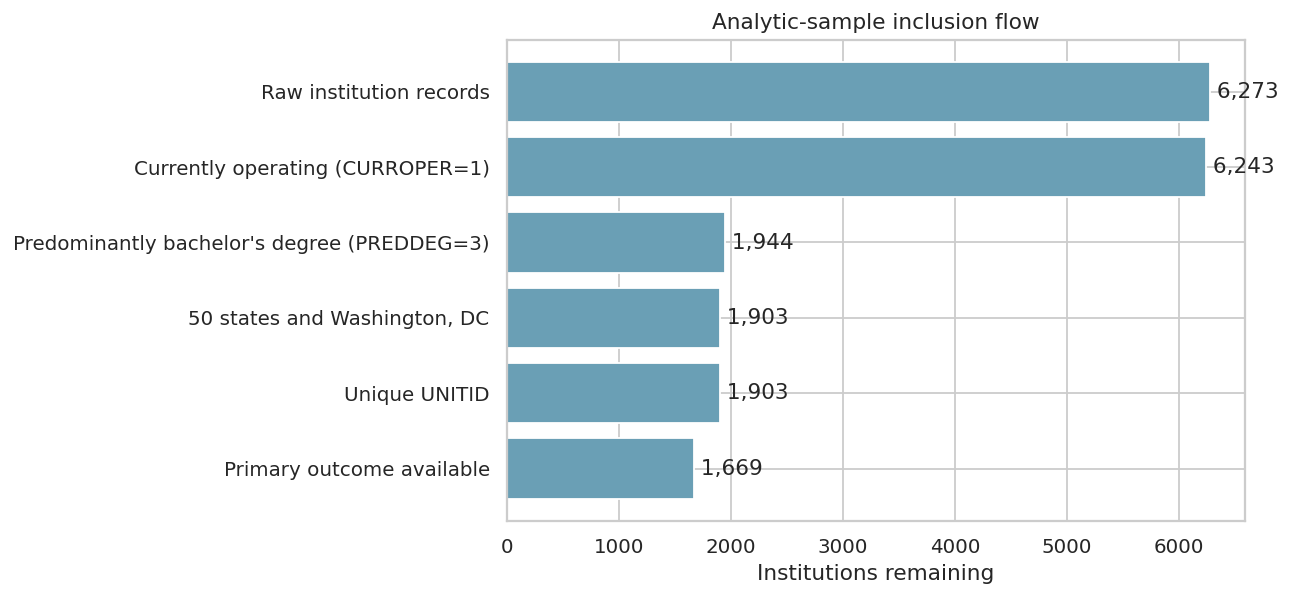

In [5]:
US_STATES_DC = {
    "AL", "AK", "AZ", "AR", "CA", "CO", "CT", "DE", "FL", "GA",
    "HI", "ID", "IL", "IN", "IA", "KS", "KY", "LA", "ME", "MD",
    "MA", "MI", "MN", "MS", "MO", "MT", "NE", "NV", "NH", "NJ",
    "NM", "NY", "NC", "ND", "OH", "OK", "OR", "PA", "RI", "SC",
    "SD", "TN", "TX", "UT", "VT", "VA", "WA", "WV", "WI", "WY", "DC",}
SUPPRESSED_TOKENS = ["PS", "PrivacySuppressed", "NULL", "null", "NA", "N/A", ""]

header = pd.read_csv(RAW_CSV, nrows=0).columns.tolist()
missing_required = sorted(set(CORE_SOURCE_COLUMNS) - set(header))
if missing_required:
    raise KeyError(f"The source file is missing required columns: {missing_required}")

raw = pd.read_csv(
    RAW_CSV,
    usecols=CORE_SOURCE_COLUMNS,
    low_memory=False,
    na_values=SUPPRESSED_TOKENS,
    keep_default_na=True,)

numeric_columns = [column for column in CORE_SOURCE_COLUMNS if column not in ["INSTNM", "STABBR"]]
for column in numeric_columns:
    raw[column] = pd.to_numeric(raw[column], errors="coerce")
raw["STABBR"] = raw["STABBR"].astype("string").str.strip().str.upper()

flow = []
def record_flow(step: str, frame: pd.DataFrame) -> None:
    flow.append({"step": step, "remaining_n": len(frame)})

record_flow("Raw institution records", raw)
eligible = raw.loc[raw["CURROPER"].eq(1)].copy()
record_flow("Currently operating (CURROPER=1)", eligible)
eligible = eligible.loc[eligible["PREDDEG"].eq(3)].copy()
record_flow("Predominantly bachelor's degree (PREDDEG=3)", eligible)
eligible = eligible.loc[eligible["STABBR"].isin(US_STATES_DC)].copy()
record_flow("50 states and Washington, DC", eligible)

duplicate_ids = eligible.loc[eligible["UNITID"].duplicated(keep=False), ["UNITID", "INSTNM"]]
if not duplicate_ids.empty:
    save_table(duplicate_ids, "02_duplicate_unitids_flagged.csv")
    raise ValueError("Duplicate UNITID values were found. Inspect 02_duplicate_unitids_flagged.csv before proceeding.")
record_flow("Unique UNITID", eligible)

eligible["NET_PRICE"] = np.where(
    eligible["CONTROL"].eq(1), eligible["NPT4_PUB"], eligible["NPT4_PRIV"])
eligible["CONTROL_LABEL"] = eligible["CONTROL"].map(
    {1: "Public", 2: "Private nonprofit", 3: "Private for-profit"})
eligible["REGION_LABEL"] = eligible["REGION"].astype("Int64").astype("string")

def collapse_locale(value):
    if pd.isna(value):
        return np.nan
    value = int(value)
    if 11 <= value <= 13:
        return "City"
    if 21 <= value <= 23:
        return "Suburb"
    if 31 <= value <= 33:
        return "Town"
    if 41 <= value <= 43:
        return "Rural"
    return np.nan

eligible["LOCALE4"] = eligible["LOCALE"].map(collapse_locale)
analytic = eligible.loc[eligible["C150_4_POOLED_SUPP"].notna()].copy()
record_flow("Primary outcome available", analytic)

range_rules = {
    "C150_4_POOLED_SUPP": (0, 1), "C150_4": (0, 1), "PCTPELL": (0, 1),
    "PCTFLOAN": (0, 1), "ADM_RATE_SUPP": (0, 1), "NET_PRICE": (0, np.inf),
    "UGDS": (0, np.inf), "INEXPFTE": (0, np.inf), "AVGFACSAL": (0, np.inf),
    "STUFACR": (0, np.inf),}
range_flags = []
for column, (lower, upper) in range_rules.items():
    invalid = analytic[column].notna() & ((analytic[column] < lower) | (analytic[column] > upper))
    range_flags.append({"variable": column, "invalid_n": int(invalid.sum())})
    analytic.loc[invalid, column] = np.nan
range_flags = pd.DataFrame(range_flags)
save_table(range_flags, "03_range_validation.csv")

for source, derived in {
    "NET_PRICE": "LOG_NET_PRICE", "UGDS": "LOG_UGDS",
    "INEXPFTE": "LOG_INEXPFTE", "AVGFACSAL": "LOG_AVGFACSAL",
}.items():
    analytic[derived] = np.log1p(analytic[source].clip(lower=0))

assert analytic["UNITID"].is_unique
assert analytic["C150_4_POOLED_SUPP"].between(0, 1).all()
assert len(analytic) >= MIN_ANALYTIC_N, (
    f"Analytic N={len(analytic)} is below the pre-specified minimum of {MIN_ANALYTIC_N}. "
    "Do not report confirmatory results without revising the design before analysis.")

flow_table = pd.DataFrame(flow)
flow_table["removed_since_prior_step"] = -flow_table["remaining_n"].diff().fillna(0).astype(int)
save_table(flow_table, "04_inclusion_flow.csv")
analytic.sort_values("UNITID").to_csv(
    PROCESSED_DIR / "college_graduation_analysis.csv", index=False)

print(f"Final analytic N: {len(analytic):,}")
display(flow_table)
display(range_flags)

plt.figure(figsize=(10, 4.8))
plot_flow = flow_table.iloc[::-1]
plt.barh(plot_flow["step"], plot_flow["remaining_n"], color="#6A9FB5")
for position, value in enumerate(plot_flow["remaining_n"]):
    plt.text(value, position, f" {value:,}", va="center")
plt.xlabel("Institutions remaining")
plt.title("Analytic-sample inclusion flow")
plt.tight_layout()
save_figure("00_inclusion_flow.png")
plt.show()


### Data-quality report

Variables missing more than 40% are automatically excluded from the predictive feature set. The core data are otherwise retained, with training-fold imputation performed inside each model pipeline. Extreme but plausible observations remain in the primary analysis and are examined in sensitivity checks.

In [6]:
MODEL_CANDIDATE_COLUMNS = [
    "LOG_NET_PRICE", "PCTPELL", "PCTFLOAN", "LOG_UGDS", "ADM_RATE_SUPP",
    "LOG_INEXPFTE", "LOG_AVGFACSAL", "STUFACR", "CONTROL_LABEL",
    "REGION_LABEL", "LOCALE4",]
missingness = (
    analytic[MODEL_CANDIDATE_COLUMNS + ["C150_4_POOLED_SUPP", "C150_4"]]
    .isna().mean().mul(100).rename("missing_percent").to_frame())
missingness["missing_n"] = analytic[missingness.index].isna().sum().values
missingness["core_model_status"] = np.where(
    missingness["missing_percent"] > 40, "Exclude (>40% missing)", "Retain")
save_table(missingness.reset_index(names="variable"), "05_missingness.csv")
display(missingness.sort_values("missing_percent", ascending=False))

excluded_for_missingness = missingness.index[
    (missingness["missing_percent"] > 40) & missingness.index.isin(MODEL_CANDIDATE_COLUMNS)
].tolist()
if excluded_for_missingness:
    print("Excluded from core predictive model:", excluded_for_missingness)

MODEL_COLUMNS = [column for column in MODEL_CANDIDATE_COLUMNS if column not in excluded_for_missingness]
AFFORDABILITY_FEATURES = [column for column in ["LOG_NET_PRICE", "PCTPELL", "PCTFLOAN"] if column in MODEL_COLUMNS]
NUMERIC_FULL = [
    column for column in ["LOG_NET_PRICE", "PCTPELL", "PCTFLOAN", "LOG_UGDS",
                           "ADM_RATE_SUPP", "LOG_INEXPFTE", "LOG_AVGFACSAL", "STUFACR"]
    if column in MODEL_COLUMNS]
CATEGORICAL_FULL = [column for column in ["CONTROL_LABEL", "REGION_LABEL", "LOCALE4"] if column in MODEL_COLUMNS]
NUMERIC_REDUCED = [column for column in NUMERIC_FULL if column not in AFFORDABILITY_FEATURES]
CATEGORICAL_REDUCED = CATEGORICAL_FULL.copy()

assert len(AFFORDABILITY_FEATURES) == 3, "All three pre-specified affordability features are required for RQ1 and RQ4."
print("Full model features:", NUMERIC_FULL + CATEGORICAL_FULL)
print("Reduced model features:", NUMERIC_REDUCED + CATEGORICAL_REDUCED)

variable_dictionary = pd.DataFrame([
    ("UNITID", "Identifier", "College identifier", "Audit key only"),
    ("C150_4_POOLED_SUPP", "Continuous, 0–1", "Pooled completion within 150% of normal time", "Primary outcome"),
    ("C150_4", "Continuous, 0–1", "Unpooled completion within 150% of normal time", "Sensitivity outcome"),
    ("NET_PRICE", "Continuous, USD", "NPT4_PUB for public colleges; otherwise NPT4_PRIV", "Affordability source field"),
    ("LOG_NET_PRICE", "Continuous", "log(1 + NET_PRICE)", "Affordability predictor"),
    ("PCTPELL", "Continuous, 0–1", "Share receiving a Pell Grant", "Affordability/need predictor"),
    ("PCTFLOAN", "Continuous, 0–1", "Share receiving a federal student loan", "Affordability/financing predictor"),
    ("ADM_RATE_SUPP", "Continuous, 0–1", "Suppression-adjusted admission rate", "Optional selectivity control"),
    ("LOG_UGDS", "Continuous", "log(1 + undergraduate enrollment)", "Size control"),
    ("LOG_INEXPFTE", "Continuous", "log(1 + instructional expenditure per FTE)", "Resource predictor"),
    ("LOG_AVGFACSAL", "Continuous", "log(1 + average monthly faculty salary)", "Resource predictor"),
    ("STUFACR", "Continuous", "Student-to-faculty ratio", "Resource predictor"),
    ("CONTROL_LABEL", "Categorical", "Public, private nonprofit, private for-profit", "Organizational predictor/group"),
    ("REGION_LABEL", "Categorical", "IPEDS region code", "Geographic control"),
    ("LOCALE4", "Categorical", "City, suburb, town, rural", "Location predictor/group"),
], columns=["variable", "type_or_unit", "definition", "analysis_role"])
save_table(variable_dictionary, "05b_analysis_variable_dictionary.csv")
display(variable_dictionary)


Full model features: ['LOG_NET_PRICE', 'PCTPELL', 'PCTFLOAN', 'LOG_UGDS', 'ADM_RATE_SUPP', 'LOG_INEXPFTE', 'LOG_AVGFACSAL', 'STUFACR', 'CONTROL_LABEL', 'REGION_LABEL', 'LOCALE4']
Reduced model features: ['LOG_UGDS', 'ADM_RATE_SUPP', 'LOG_INEXPFTE', 'LOG_AVGFACSAL', 'STUFACR', 'CONTROL_LABEL', 'REGION_LABEL', 'LOCALE4']


,missing_percent,missing_n,core_model_status
ADM_RATE_SUPP,13.361294,223,Retain
LOG_NET_PRICE,2.037148,34,Retain
LOG_AVGFACSAL,1.018574,17,Retain
PCTFLOAN,0.239664,4,Retain
PCTPELL,0.239664,4,Retain
C150_4,0.179748,3,Retain
LOG_UGDS,0.000000,0,Retain
STUFACR,0.000000,0,Retain
LOG_INEXPFTE,0.000000,0,Retain
CONTROL_LABEL,0.000000,0,Retain


,variable,type_or_unit,definition,analysis_role
0,UNITID,Identifier,College identifier,Audit key only
1,C150_4_POOLED_SUPP,"Continuous, 0–1",Pooled completion within 150% of normal time,Primary outcome
2,C150_4,"Continuous, 0–1",Unpooled completion within 150% of normal time,Sensitivity outcome
3,NET_PRICE,"Continuous, USD",NPT4_PUB for public colleges; otherwise NPT4_PRIV,Affordability source field
4,LOG_NET_PRICE,Continuous,log(1 + NET_PRICE),Affordability predictor
5,PCTPELL,"Continuous, 0–1",Share receiving a Pell Grant,Affordability/need predictor
6,PCTFLOAN,"Continuous, 0–1",Share receiving a federal student loan,Affordability/financing predictor
7,ADM_RATE_SUPP,"Continuous, 0–1",Suppression-adjusted admission rate,Optional selectivity control
8,LOG_UGDS,Continuous,log(1 + undergraduate enrollment),Size control
9,LOG_INEXPFTE,Continuous,log(1 + instructional expenditure per FTE),Resource predictor


## 4. Exploratory data analysis

Descriptive summaries report proportions on the 0–1 analysis scale and figures display graduation rates as percentages. The graphics correspond to the planned distribution, group, affordability, resource, missingness, and correlation checks.

In [7]:
continuous_display = [
    "C150_4_POOLED_SUPP", "NET_PRICE", "PCTPELL", "PCTFLOAN", "ADM_RATE_SUPP",
    "UGDS", "INEXPFTE", "AVGFACSAL", "STUFACR",]
descriptive = analytic[continuous_display].describe(percentiles=[0.25, 0.5, 0.75]).T
descriptive["missing_n"] = analytic[continuous_display].isna().sum()
descriptive["missing_percent"] = analytic[continuous_display].isna().mean() * 100
descriptive["iqr"] = descriptive["75%"] - descriptive["25%"]
descriptive = descriptive[["count", "missing_n", "missing_percent", "mean", "std", "min", "25%", "50%", "75%", "iqr", "max"]]
save_table(descriptive.reset_index(names="variable"), "06_continuous_descriptives.csv")

category_rows = []
for column in ["CONTROL_LABEL", "LOCALE4", "REGION_LABEL"]:
    counts = analytic[column].fillna("Missing").value_counts(dropna=False)
    for level, count in counts.items():
        category_rows.append({"variable": column, "level": level, "n": count, "percent": 100 * count / len(analytic)})
categorical_summary = pd.DataFrame(category_rows)
save_table(categorical_summary, "07_categorical_descriptives.csv")
display(descriptive.round(4))
display(categorical_summary)

skewness_table = pd.DataFrame([
    {"source_variable": "NET_PRICE", "raw_skewness": analytic["NET_PRICE"].skew(), "transformed_variable": "LOG_NET_PRICE", "transformed_skewness": analytic["LOG_NET_PRICE"].skew()},
    {"source_variable": "UGDS", "raw_skewness": analytic["UGDS"].skew(), "transformed_variable": "LOG_UGDS", "transformed_skewness": analytic["LOG_UGDS"].skew()},
    {"source_variable": "INEXPFTE", "raw_skewness": analytic["INEXPFTE"].skew(), "transformed_variable": "LOG_INEXPFTE", "transformed_skewness": analytic["LOG_INEXPFTE"].skew()},
    {"source_variable": "AVGFACSAL", "raw_skewness": analytic["AVGFACSAL"].skew(), "transformed_variable": "LOG_AVGFACSAL", "transformed_skewness": analytic["LOG_AVGFACSAL"].skew()},])
save_table(skewness_table, "07b_transformation_skewness_check.csv")
display(skewness_table.round(3))


,count,missing_n,missing_percent,mean,std,min,25%,50%,75%,iqr,max
C150_4_POOLED_SUPP,1669.0,0,0.0000,0.5527,0.1909,0.0000,0.4299,0.5581,0.6835,0.2536,1.0000
NET_PRICE,1635.0,34,2.0371,21193.4275,9276.7249,992.0000,14820.5000,20146.0000,26142.5000,11322.0000,73043.0000
PCTPELL,1665.0,4,0.2397,0.3502,0.1637,0.0000,0.2327,0.3279,0.4373,0.2046,0.9689
PCTFLOAN,1665.0,4,0.2397,0.4460,0.2067,0.0000,0.3158,0.4498,0.5978,0.2820,1.0000
ADM_RATE_SUPP,1446.0,223,13.3613,0.7143,0.2253,0.0257,0.6128,0.7666,0.8839,0.2711,1.0000
UGDS,1669.0,0,0.0000,5117.9101,9852.4270,6.0000,836.0000,1839.0000,5166.0000,4330.0000,163164.0000
INEXPFTE,1669.0,0,0.0000,13000.1372,11617.7103,0.0000,7476.0000,10551.0000,14663.0000,7187.0000,181929.0000
AVGFACSAL,1652.0,17,1.0186,8957.3614,3102.0346,1050.0000,7017.5000,8484.5000,10460.5000,3443.0000,25354.0000
STUFACR,1669.0,0,0.0000,13.9347,6.1805,1.0000,11.0000,13.0000,16.0000,5.0000,147.0000


,variable,level,n,percent
0,CONTROL_LABEL,Private nonprofit,1042,62.432594
1,CONTROL_LABEL,Public,553,33.133613
2,CONTROL_LABEL,Private for-profit,74,4.433793
3,LOCALE4,City,825,49.430797
4,LOCALE4,Suburb,391,23.427202
5,LOCALE4,Town,314,18.813661
6,LOCALE4,Rural,139,8.328340
7,REGION_LABEL,5,416,24.925105
8,REGION_LABEL,2,346,20.730977
9,REGION_LABEL,3,249,14.919113


,source_variable,raw_skewness,transformed_variable,transformed_skewness
0,NET_PRICE,0.921,LOG_NET_PRICE,-0.814
1,UGDS,6.693,LOG_UGDS,-0.196
2,INEXPFTE,5.855,LOG_INEXPFTE,-2.659
3,AVGFACSAL,1.163,LOG_AVGFACSAL,-0.658


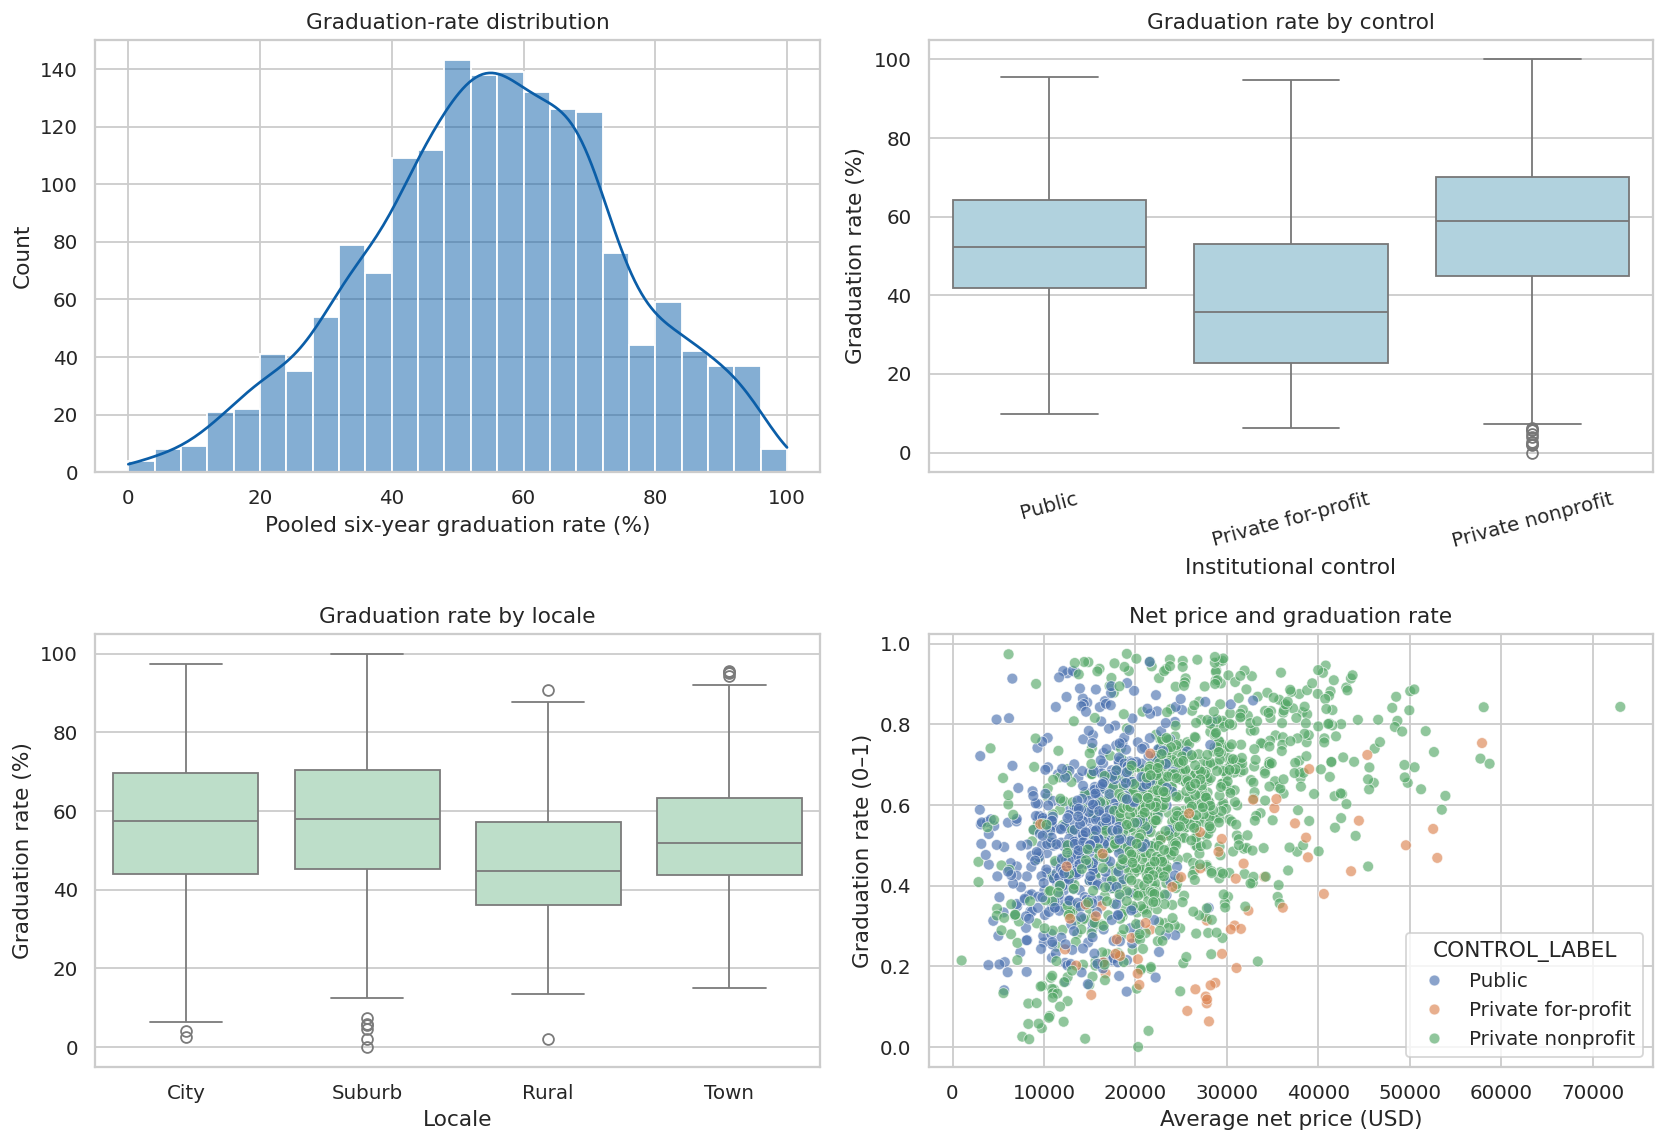

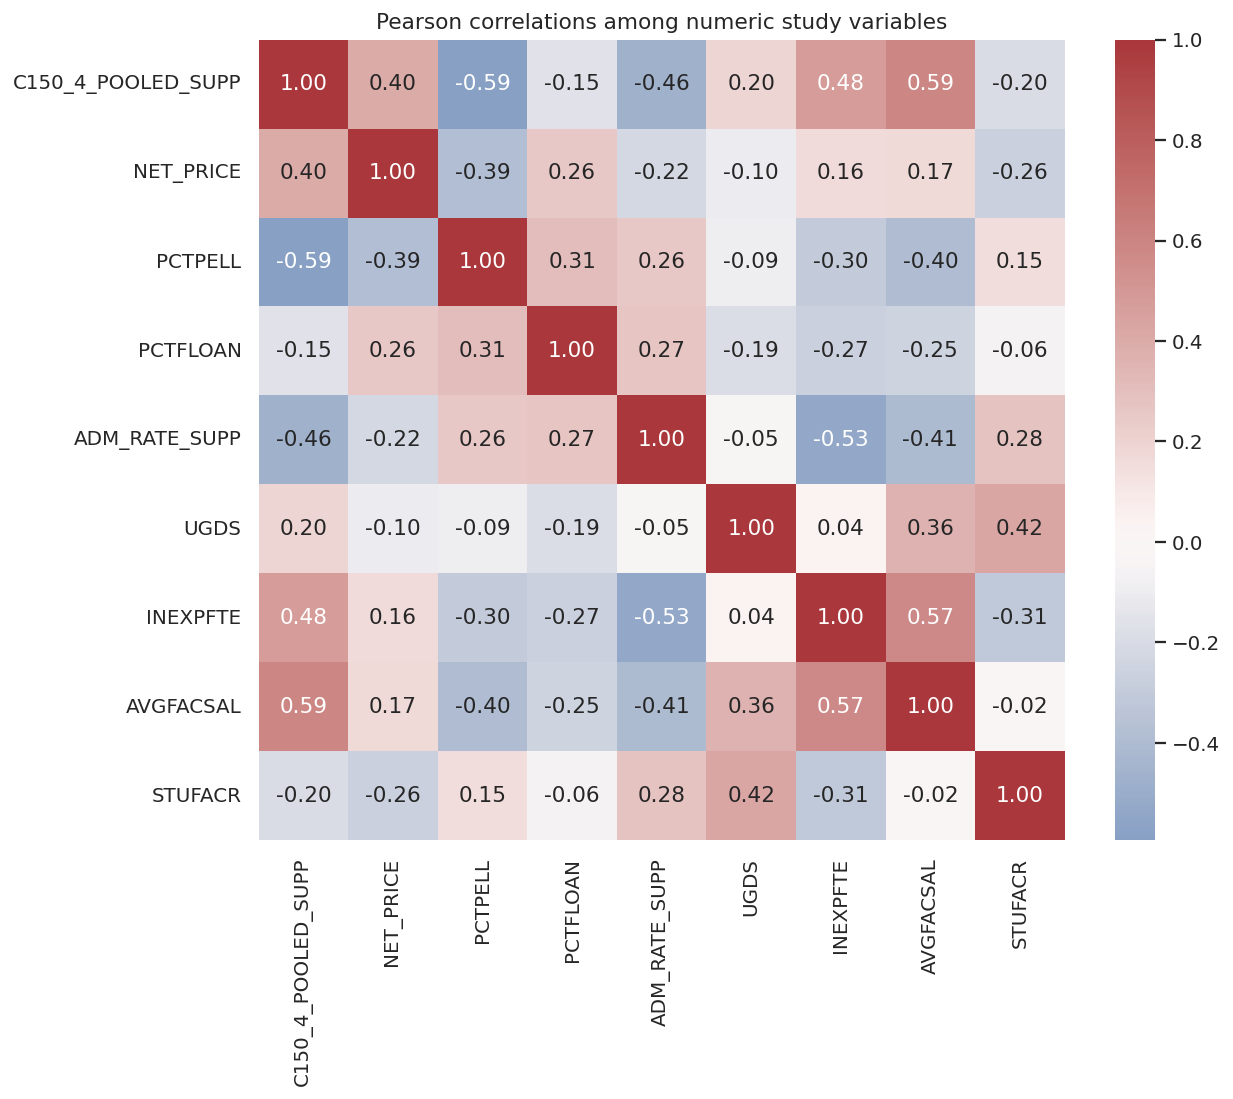

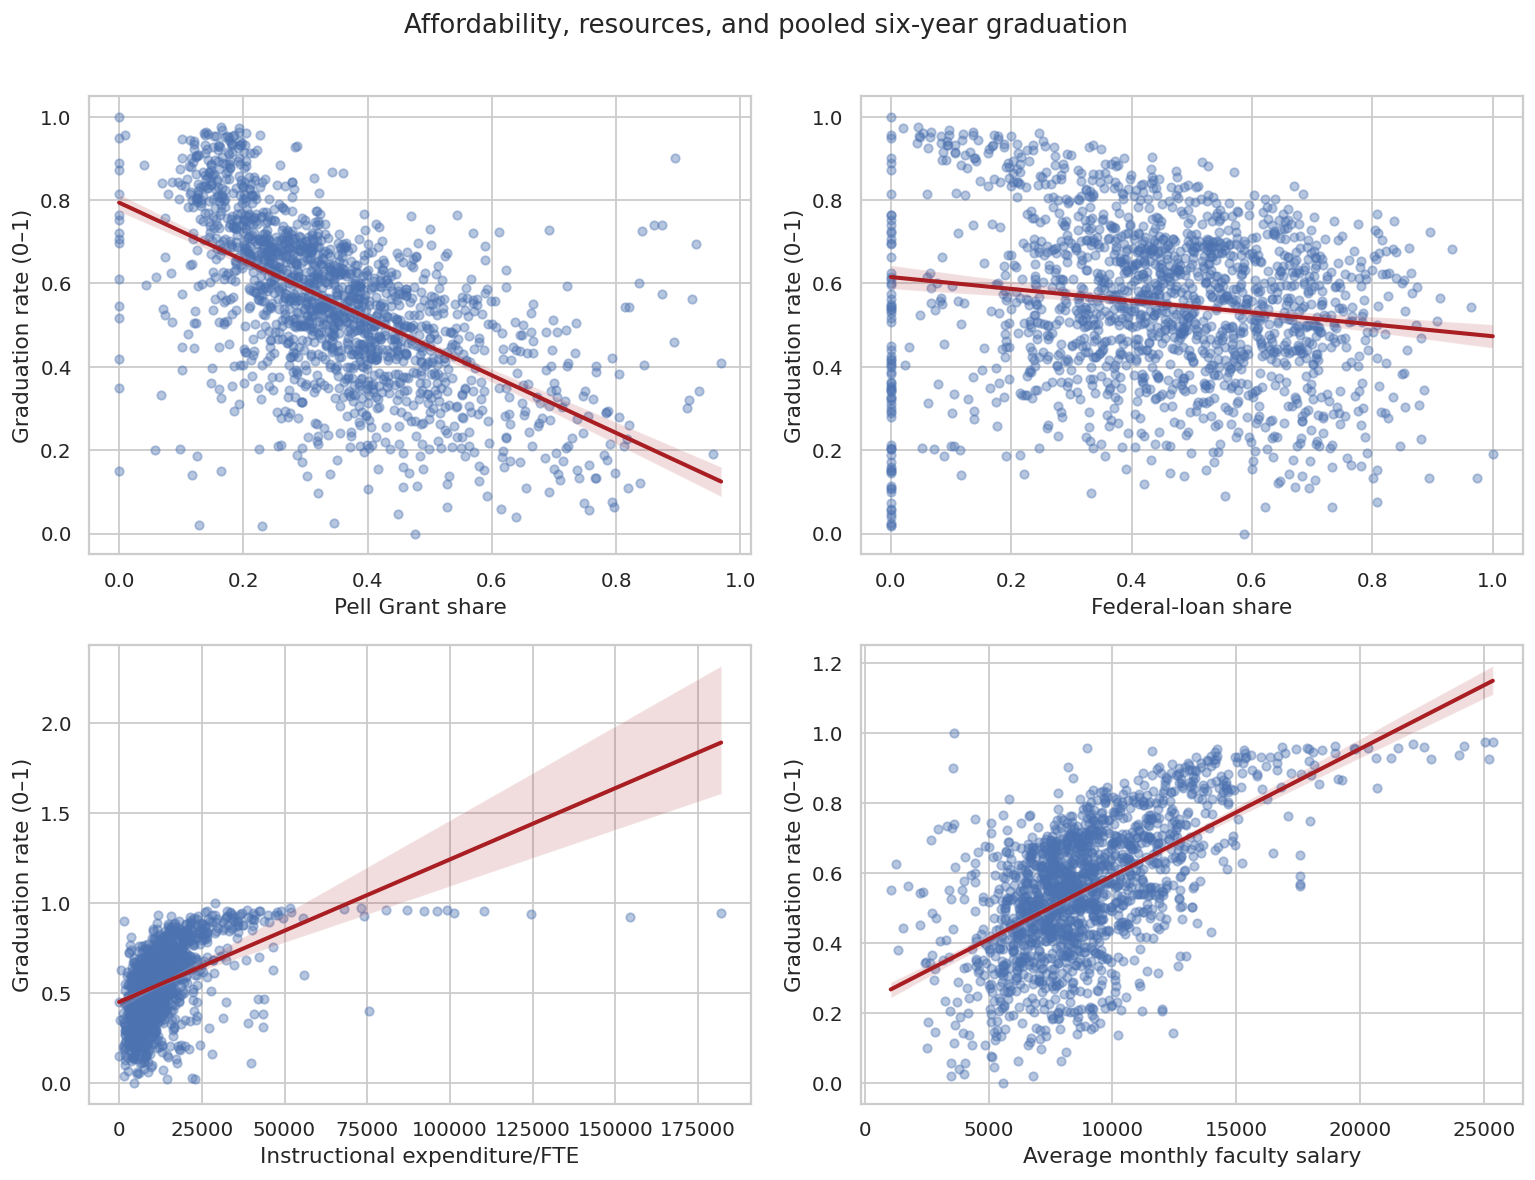

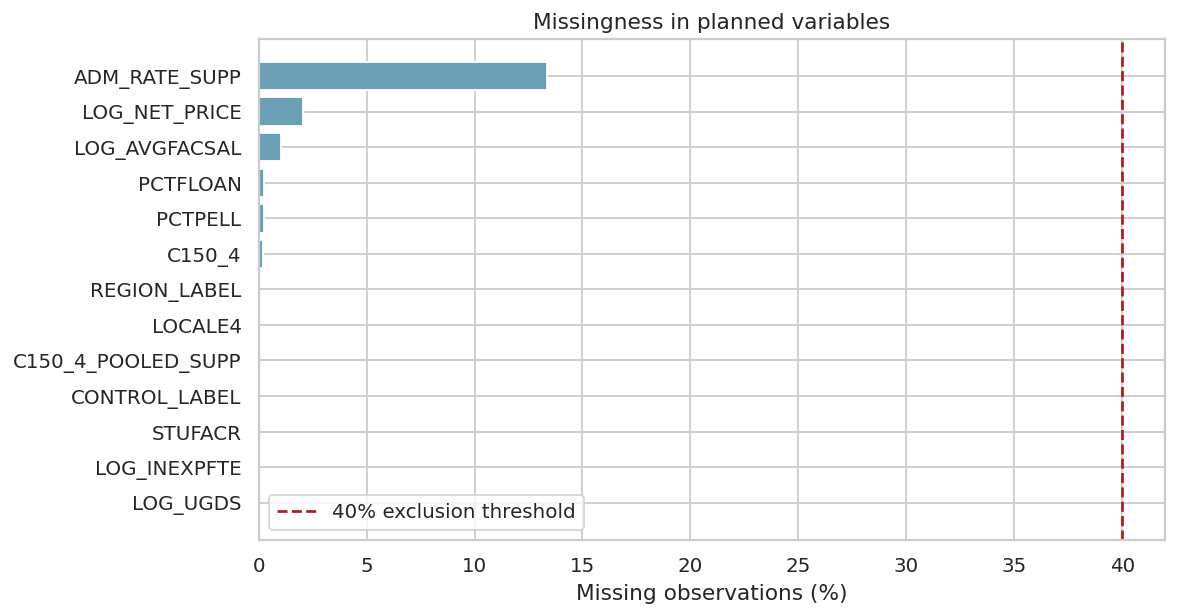

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
sns.histplot(analytic["C150_4_POOLED_SUPP"] * 100, bins=25, kde=True, ax=axes[0, 0], color="#0B5EA8")
axes[0, 0].set(xlabel="Pooled six-year graduation rate (%)", title="Graduation-rate distribution")
sns.boxplot(data=analytic, x="CONTROL_LABEL", y=analytic["C150_4_POOLED_SUPP"] * 100, ax=axes[0, 1], color="#A9D6E5")
axes[0, 1].set(xlabel="Institutional control", ylabel="Graduation rate (%)", title="Graduation rate by control")
axes[0, 1].tick_params(axis="x", rotation=15)
sns.boxplot(data=analytic, x="LOCALE4", y=analytic["C150_4_POOLED_SUPP"] * 100, ax=axes[1, 0], color="#B7E4C7")
axes[1, 0].set(xlabel="Locale", ylabel="Graduation rate (%)", title="Graduation rate by locale")
sns.scatterplot(data=analytic, x="NET_PRICE", y="C150_4_POOLED_SUPP", hue="CONTROL_LABEL", alpha=0.65, ax=axes[1, 1])
axes[1, 1].set(xlabel="Average net price (USD)", ylabel="Graduation rate (0–1)", title="Net price and graduation rate")
plt.tight_layout()
save_figure("01_primary_eda.png")
plt.show()

numeric_corr_columns = ["C150_4_POOLED_SUPP", "NET_PRICE", "PCTPELL", "PCTFLOAN", "ADM_RATE_SUPP", "UGDS", "INEXPFTE", "AVGFACSAL", "STUFACR"]
corr = analytic[numeric_corr_columns].corr(method="pearson")
save_table(corr.reset_index(names="variable"), "08_numeric_correlations.csv")
plt.figure(figsize=(10, 8))
sns.heatmap(corr, cmap="vlag", center=0, annot=True, fmt=".2f", square=False)
plt.title("Pearson correlations among numeric study variables")
save_figure("02_correlation_heatmap.png")
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
for ax, feature, label in zip(
    axes.ravel(),
    ["PCTPELL", "PCTFLOAN", "INEXPFTE", "AVGFACSAL"],
    ["Pell Grant share", "Federal-loan share", "Instructional expenditure/FTE", "Average monthly faculty salary"],):
    sns.regplot(data=analytic, x=feature, y="C150_4_POOLED_SUPP", scatter_kws={"alpha": 0.4, "s": 22}, line_kws={"color": "#A81E22"}, ax=ax)
    ax.set(xlabel=label, ylabel="Graduation rate (0–1)")
plt.suptitle("Affordability, resources, and pooled six-year graduation", y=1.01)
plt.tight_layout()
save_figure("01b_affordability_resource_scatterplots.png")
plt.show()

plt.figure(figsize=(9, 5))
plot_missing = missingness.sort_values("missing_percent", ascending=True)
plt.barh(plot_missing.index, plot_missing["missing_percent"], color="#6A9FB5")
plt.axvline(40, color="#A81E22", linestyle="--", label="40% exclusion threshold")
plt.xlabel("Missing observations (%)")
plt.title("Missingness in planned variables")
plt.legend()
save_figure("03_missingness.png")
plt.show()


## 5. RQ1: Adjusted affordability associations

The confirmatory model uses OLS with HC3 robust standard errors. The joint affordability test evaluates the three pre-specified coefficients together. Partial $R^2$ compares the full and reduced models. Diagnostics include variance inflation factors, residual plots, heteroskedasticity, leverage, and Cook's distance. A logit-transformed-outcome model is reported as a bounded-outcome sensitivity check.

In [9]:
TARGET = "C150_4_POOLED_SUPP"
INFERENCE_NUMERIC = [
    "LOG_NET_PRICE", "PCTPELL", "PCTFLOAN", "LOG_UGDS", "ADM_RATE_SUPP",
    "LOG_INEXPFTE", "LOG_AVGFACSAL", "STUFACR",]
stats_df = analytic[[TARGET, "CONTROL_LABEL", "REGION_LABEL", "LOCALE4", *INFERENCE_NUMERIC]].copy()

for column in INFERENCE_NUMERIC:
    if stats_df[column].isna().any():
        stats_df[f"{column}_MISSING"] = stats_df[column].isna().astype(int)
        stats_df[column] = stats_df[column].fillna(stats_df[column].median())
for column in ["CONTROL_LABEL", "REGION_LABEL", "LOCALE4"]:
    stats_df[column] = stats_df[column].fillna("Unknown").astype(str)

missing_terms = [column for column in stats_df.columns if column.endswith("_MISSING")]
duplicate_missing_flags = stats_df[missing_terms].T.duplicated()
duplicate_flag_names = duplicate_missing_flags[duplicate_missing_flags].index.tolist()
missing_terms = [name for name in missing_terms if name not in duplicate_flag_names]
print("Removed duplicate missing indicators:", duplicate_flag_names)
adjustment_numeric = ["LOG_UGDS", "ADM_RATE_SUPP", "LOG_INEXPFTE", "LOG_AVGFACSAL", "STUFACR"]
affordability_terms = ["LOG_NET_PRICE", "PCTPELL", "PCTFLOAN"]
categorical_terms = ["C(CONTROL_LABEL)", "C(REGION_LABEL)", "C(LOCALE4)"]

full_terms = affordability_terms + adjustment_numeric + missing_terms + categorical_terms
reduced_terms = adjustment_numeric + missing_terms + categorical_terms
rq1_formula = TARGET + " ~ " + " + ".join(full_terms)
rq1_reduced_formula = TARGET + " ~ " + " + ".join(reduced_terms)

rq1_classical = smf.ols(rq1_formula, data=stats_df).fit()
rq1 = rq1_classical.get_robustcov_results(cov_type="HC3")
rq1_reduced = smf.ols(rq1_reduced_formula, data=stats_df).fit()

param_names = rq1_classical.model.exog_names
params = pd.Series(np.asarray(rq1.params), index=param_names)
conf = pd.DataFrame(np.asarray(rq1.conf_int(alpha=ALPHA)), index=param_names, columns=["ci_lower", "ci_upper"])
rq1_table = pd.DataFrame({
    "term": param_names,
    "coefficient": params.values,
    "std_error_hc3": np.asarray(rq1.bse),
    "t": np.asarray(rq1.tvalues),
    "p_value": np.asarray(rq1.pvalues),
    "ci_lower": conf["ci_lower"].values,
    "ci_upper": conf["ci_upper"].values,})

standardized_df = stats_df.copy()
standardized_df["TARGET_Z"] = stats.zscore(standardized_df[TARGET], ddof=0)
z_names = {}
for column in affordability_terms + adjustment_numeric:
    z_name = f"Z_{column}"
    standardized_df[z_name] = stats.zscore(standardized_df[column], ddof=0)
    z_names[column] = z_name
standardized_formula = "TARGET_Z ~ " + " + ".join(
    [z_names.get(term, term) for term in affordability_terms + adjustment_numeric] + missing_terms + categorical_terms)
rq1_standardized = smf.ols(standardized_formula, data=standardized_df).fit(cov_type="HC3")
standardized_lookup = rq1_standardized.params.to_dict()
rq1_table["standardized_beta"] = rq1_table["term"].map(
    {term: standardized_lookup.get(z_names[term], np.nan) for term in affordability_terms})

constraint_names = affordability_terms
R = np.zeros((len(constraint_names), len(param_names)))
for row, name in enumerate(constraint_names):
    R[row, param_names.index(name)] = 1
joint_test = rq1.f_test(R)
delta_r2 = rq1_classical.rsquared - rq1_reduced.rsquared
partial_r2 = delta_r2 / (1 - rq1_reduced.rsquared)
rq1_block = pd.DataFrame([{
    "test": "Joint affordability block (HC3)",
    "F": float(np.asarray(joint_test.fvalue).squeeze()),
    "df_num": len(constraint_names),
    "df_den": float(rq1.df_resid),
    "p_value": float(np.asarray(joint_test.pvalue).squeeze()),
    "full_r2": rq1_classical.rsquared,
    "full_adjusted_r2": rq1_classical.rsquared_adj,
    "reduced_r2": rq1_reduced.rsquared,
    "delta_r2": delta_r2,
    "partial_r2": partial_r2,}])
save_table(rq1_table, "09_rq1_hc3_coefficients.csv")
save_table(rq1_block, "10_rq1_affordability_block_test.csv")
display(rq1_block.round(5))
display(rq1_table.loc[rq1_table["term"].isin(affordability_terms)].round(5))


Removed duplicate missing indicators: ['PCTFLOAN_MISSING']


,test,F,df_num,df_den,p_value,full_r2,full_adjusted_r2,reduced_r2,delta_r2,partial_r2
0,Joint affordability block (HC3),59.80418,3,1643.0,0.0,0.647,0.64163,0.57976,0.06724,0.16001


,term,coefficient,std_error_hc3,t,p_value,ci_lower,ci_upper,standardized_beta
14,LOG_NET_PRICE,0.02268,0.01269,1.78675,0.07416,-0.00222,0.04758,0.05596
15,PCTPELL,-0.34634,0.04074,-8.50148,0.00000,-0.42625,-0.26643,-0.29672
16,PCTFLOAN,-0.02050,0.03019,-0.67899,0.49724,-0.07971,0.03871,-0.02217


/workspace/scratch/0a241a8fa247/tmp/nbexec_env/lib/python3.12/site-packages/statsmodels/stats/outliers_influence.py:847: RuntimeWarning: invalid value encountered in sqrt
  return self.resid / sigma / np.sqrt(1 - hii)


,breusch_pagan_LM,breusch_pagan_p,breusch_pagan_F,breusch_pagan_F_p,max_cooks_d,cooks_d_over_4_over_n,max_leverage
0,392.72265,0.0,20.22267,0.0,0.39268,118,1.0


,term,VIF
6,C(REGION_LABEL)[T.5],318.505
3,C(REGION_LABEL)[T.2],279.595
4,C(REGION_LABEL)[T.3],216.144
5,C(REGION_LABEL)[T.4],162.707
9,C(REGION_LABEL)[T.8],153.779
2,C(REGION_LABEL)[T.1],126.167
7,C(REGION_LABEL)[T.6],121.317
8,C(REGION_LABEL)[T.7],46.498
1,C(CONTROL_LABEL)[T.Public],9.828
0,C(CONTROL_LABEL)[T.Private nonprofit],8.060


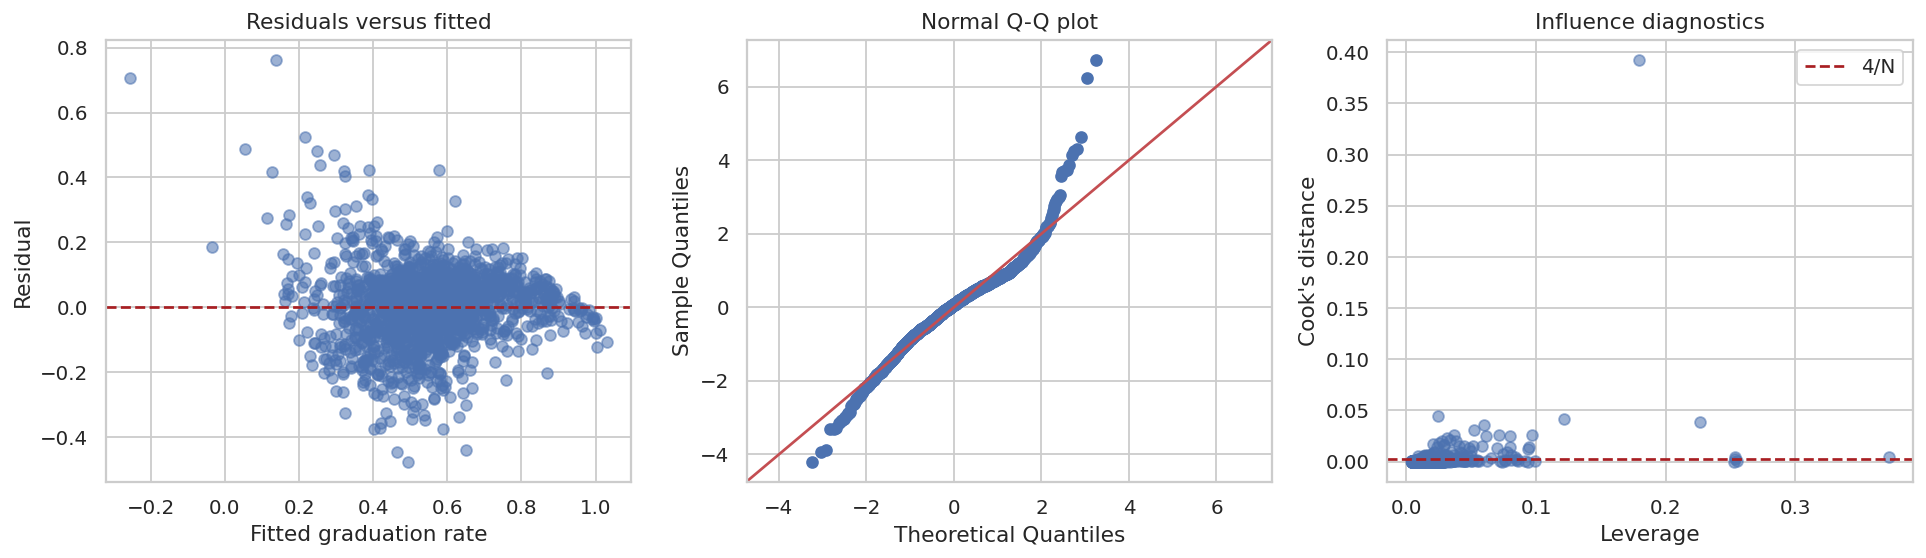

In [10]:
design = pd.DataFrame(rq1_classical.model.exog, columns=rq1_classical.model.exog_names)
vif_rows = []
for i, name in enumerate(design.columns):
    if name != "Intercept":
        vif_rows.append({"term": name, "VIF": variance_inflation_factor(design.values, i)})
vif_table = pd.DataFrame(vif_rows).sort_values("VIF", ascending=False)
save_table(vif_table, "11_rq1_vif.csv")

bp_lm, bp_lm_p, bp_f, bp_f_p = het_breuschpagan(rq1_classical.resid, rq1_classical.model.exog)
influence = rq1_classical.get_influence()
cooks_d = influence.cooks_distance[0]
leverage = influence.hat_matrix_diag
diagnostics = pd.DataFrame([{
    "breusch_pagan_LM": bp_lm,
    "breusch_pagan_p": bp_lm_p,
    "breusch_pagan_F": bp_f,
    "breusch_pagan_F_p": bp_f_p,
    "max_cooks_d": np.nanmax(cooks_d),
    "cooks_d_over_4_over_n": int((cooks_d > 4 / len(stats_df)).sum()),
    "max_leverage": np.nanmax(leverage),}])
save_table(diagnostics, "12_rq1_diagnostics.csv")

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
axes[0].scatter(rq1_classical.fittedvalues, rq1_classical.resid, alpha=0.55)
axes[0].axhline(0, color="#A81E22", linestyle="--")
axes[0].set(xlabel="Fitted graduation rate", ylabel="Residual", title="Residuals versus fitted")
sm.qqplot(rq1_classical.resid, line="45", fit=True, ax=axes[1])
axes[1].set_title("Normal Q-Q plot")
axes[2].scatter(leverage, cooks_d, alpha=0.55)
axes[2].axhline(4 / len(stats_df), color="#A81E22", linestyle="--", label="4/N")
axes[2].set(xlabel="Leverage", ylabel="Cook's distance", title="Influence diagnostics")
axes[2].legend()
plt.tight_layout()
save_figure("04_rq1_diagnostics.png")
plt.show()

eps = 1e-4
stats_df["LOGIT_TARGET"] = np.log(stats_df[TARGET].clip(eps, 1 - eps) / (1 - stats_df[TARGET].clip(eps, 1 - eps)))
rq1_logit = smf.ols("LOGIT_TARGET ~ " + " + ".join(full_terms), data=stats_df).fit(cov_type="HC3")
logit_sensitivity = pd.DataFrame({
    "term": affordability_terms,
    "coefficient": [rq1_logit.params[term] for term in affordability_terms],
    "p_value": [rq1_logit.pvalues[term] for term in affordability_terms],})

keep_influence = cooks_d <= 4 / len(stats_df)
rq1_influence_sensitivity = smf.ols(rq1_formula, data=stats_df.loc[keep_influence]).fit(cov_type="HC3")
influence_sensitivity = pd.DataFrame({
    "term": affordability_terms,
    "coefficient": [rq1_influence_sensitivity.params[term] for term in affordability_terms],
    "p_value": [rq1_influence_sensitivity.pvalues[term] for term in affordability_terms],
    "n_after_exclusion": int(keep_influence.sum()),})
save_table(logit_sensitivity, "13_rq1_logit_sensitivity.csv")
save_table(influence_sensitivity, "14_rq1_influence_sensitivity.csv")
display(diagnostics.round(5))
display(vif_table.head(15).round(3))


## 6. RQ2: Adjusted institutional-control and locale comparisons

The ANCOVA includes both group factors, the affordability measures, admissions, enrollment, resource measures, region, and missingness indicators. Adjusted marginal means average predictions over the observed covariate distribution. Global HC3 Wald tests are followed by Holm-controlled pairwise comparisons. Unadjusted eta squared and robust-model partial eta squared are both reported and labeled.

In [11]:
rq2_formula = TARGET + " ~ " + " + ".join(
    affordability_terms + adjustment_numeric + missing_terms + categorical_terms)
rq2_classical = smf.ols(rq2_formula, data=stats_df).fit()
rq2 = rq2_classical.get_robustcov_results(cov_type="HC3")
rq2_param_names = rq2_classical.model.exog_names

def global_factor_test(factor: str) -> dict:
    names = [name for name in rq2_param_names if name.startswith(f"C({factor})[")]
    R = np.zeros((len(names), len(rq2_param_names)))
    for row, name in enumerate(names):
        R[row, rq2_param_names.index(name)] = 1
    test = rq2.f_test(R)
    F = float(np.asarray(test.fvalue).squeeze())
    df_num = len(names)
    partial_eta2 = (F * df_num) / (F * df_num + rq2.df_resid)
    return {
        "factor": factor,
        "F_hc3": F,
        "df_num": df_num,
        "df_den": float(rq2.df_resid),
        "p_value": float(np.asarray(test.pvalue).squeeze()),
        "partial_eta_squared": partial_eta2,}

def unadjusted_eta_squared(frame: pd.DataFrame, factor: str, outcome: str) -> float:
    clean = frame[[factor, outcome]].dropna()
    grand = clean[outcome].mean()
    ss_between = sum(len(group) * (group[outcome].mean() - grand) ** 2 for _, group in clean.groupby(factor))
    ss_total = ((clean[outcome] - grand) ** 2).sum()
    return ss_between / ss_total

rq2_global = pd.DataFrame([global_factor_test("CONTROL_LABEL"), global_factor_test("LOCALE4")])
rq2_global["unadjusted_eta_squared"] = [
    unadjusted_eta_squared(stats_df, "CONTROL_LABEL", TARGET),
    unadjusted_eta_squared(stats_df, "LOCALE4", TARGET),]
save_table(rq2_global, "15_rq2_global_tests.csv")
display(rq2_global.round(5))


,factor,F_hc3,df_num,df_den,p_value,partial_eta_squared,unadjusted_eta_squared
0,CONTROL_LABEL,37.79805,2,1643.0,0.00000,0.04399,0.04878
1,LOCALE4,1.45581,3,1643.0,0.22484,0.00265,0.02423


,factor,level,adjusted_mean,std_error_hc3,ci_lower,ci_upper
0,CONTROL_LABEL,Private for-profit,0.5563,0.0219,0.5134,0.5992
1,CONTROL_LABEL,Private nonprofit,0.5837,0.0047,0.5745,0.5928
2,CONTROL_LABEL,Public,0.4939,0.0075,0.4791,0.5087
3,LOCALE4,City,0.5564,0.0043,0.5479,0.5649
4,LOCALE4,Rural,0.5327,0.0113,0.5105,0.5548
5,LOCALE4,Suburb,0.5557,0.0066,0.5427,0.5687
6,LOCALE4,Town,0.5482,0.0056,0.5372,0.5591


,factor,comparison,difference,std_error_hc3,t,p_unadjusted,p_holm,reject_holm_05,simultaneous_ci_lower,simultaneous_ci_upper
0,CONTROL_LABEL,Private for-profit - Private nonprofit,-0.02736,0.02301,-1.18898,0.23462,0.23462,False,-0.08251,0.02779
1,CONTROL_LABEL,Private for-profit - Public,0.06240,0.02437,2.56051,0.01054,0.02108,True,0.00400,0.12080
2,CONTROL_LABEL,Private nonprofit - Public,0.08976,0.01034,8.68469,0.00000,0.00000,True,0.06499,0.11453
3,LOCALE4,City - Rural,0.02373,0.01223,1.93992,0.05256,0.31536,False,-0.00858,0.05605
4,LOCALE4,City - Suburb,0.00071,0.00805,0.08846,0.92953,0.92953,False,-0.02056,0.02198
5,LOCALE4,City - Town,0.00824,0.00700,1.17704,0.23935,0.84308,False,-0.01025,0.02672
6,LOCALE4,Rural - Suburb,-0.02302,0.01378,-1.67034,0.09504,0.47521,False,-0.05943,0.01338
7,LOCALE4,Rural - Town,-0.01550,0.01238,-1.25194,0.21077,0.84308,False,-0.04820,0.01720
8,LOCALE4,Suburb - Town,0.00752,0.00893,0.84257,0.39959,0.84308,False,-0.01606,0.03111


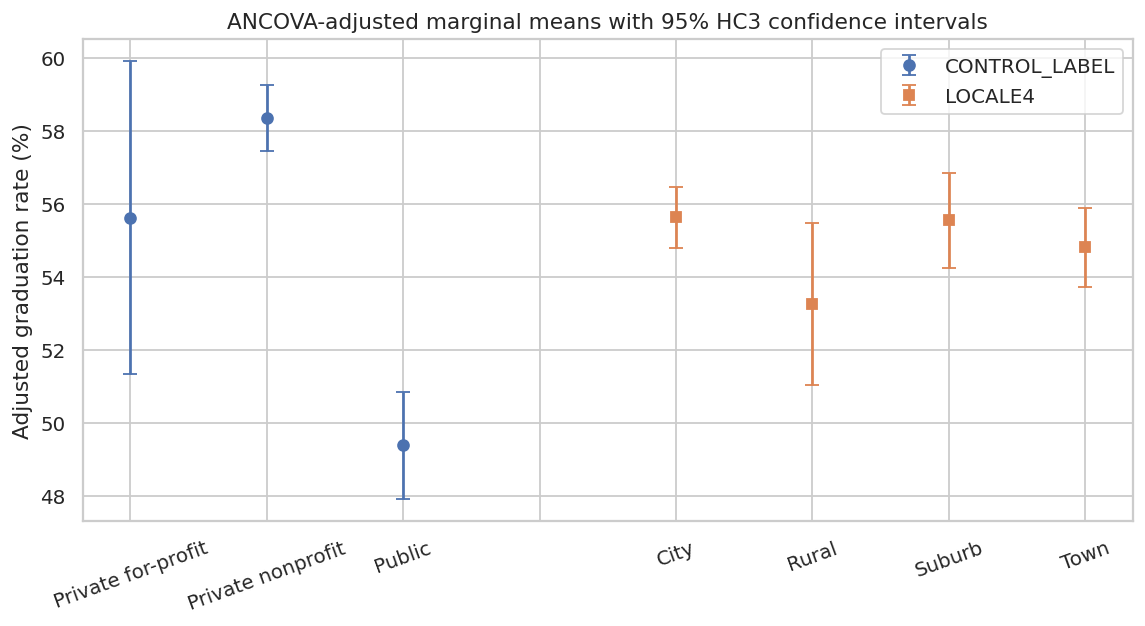

In [12]:
design_info = rq2_classical.model.data.design_info
beta = np.asarray(rq2.params)
cov_beta = np.asarray(rq2.cov_params())

def marginal_vectors(factor: str):
    levels = sorted(stats_df[factor].dropna().unique().tolist())
    rows = []
    vectors = {}
    for level in levels:
        counterfactual = stats_df.copy()
        counterfactual[factor] = level
        X_level = np.asarray(build_design_matrices([design_info], counterfactual, return_type="dataframe")[0])
        xbar = X_level.mean(axis=0)
        estimate = float(xbar @ beta)
        se = float(np.sqrt(xbar @ cov_beta @ xbar))
        critical = stats.t.ppf(1 - ALPHA / 2, rq2.df_resid)
        rows.append({
            "factor": factor, "level": level, "adjusted_mean": estimate,
            "std_error_hc3": se, "ci_lower": estimate - critical * se,
            "ci_upper": estimate + critical * se,})
        vectors[level] = xbar
    return pd.DataFrame(rows), vectors

def pairwise_from_vectors(factor: str, vectors: dict) -> pd.DataFrame:
    levels = list(vectors)
    rows = []
    for i in range(len(levels)):
        for j in range(i + 1, len(levels)):
            contrast = vectors[levels[i]] - vectors[levels[j]]
            estimate = float(contrast @ beta)
            se = float(np.sqrt(contrast @ cov_beta @ contrast))
            t_value = estimate / se
            p_value = 2 * stats.t.sf(abs(t_value), rq2.df_resid)
            rows.append({
                "factor": factor, "comparison": f"{levels[i]} - {levels[j]}",
                "difference": estimate, "std_error_hc3": se,
                "t": t_value, "p_unadjusted": p_value,})
    result = pd.DataFrame(rows)
    if not result.empty:
        reject, p_holm, _, _ = multipletests(result["p_unadjusted"], alpha=ALPHA, method="holm")
        result["p_holm"] = p_holm
        result["reject_holm_05"] = reject
        critical = stats.t.ppf(1 - ALPHA / (2 * len(result)), rq2.df_resid)
        result["simultaneous_ci_lower"] = result["difference"] - critical * result["std_error_hc3"]
        result["simultaneous_ci_upper"] = result["difference"] + critical * result["std_error_hc3"]
    return result

adjusted_frames = []
pairwise_frames = []
for factor in ["CONTROL_LABEL", "LOCALE4"]:
    means, vectors = marginal_vectors(factor)
    adjusted_frames.append(means)
    pairwise_frames.append(pairwise_from_vectors(factor, vectors))
adjusted_means = pd.concat(adjusted_frames, ignore_index=True)
rq2_pairwise = pd.concat(pairwise_frames, ignore_index=True)
save_table(adjusted_means, "16_rq2_adjusted_marginal_means.csv")
save_table(rq2_pairwise, "17_rq2_pairwise_holm.csv")
display(adjusted_means.round(4))
display(rq2_pairwise.round(5))

plt.figure(figsize=(9, 5))
plot_means = adjusted_means.copy()
plot_means["adjusted_percent"] = plot_means["adjusted_mean"] * 100
plot_means["lower_percent"] = plot_means["ci_lower"] * 100
plot_means["upper_percent"] = plot_means["ci_upper"] * 100
for factor, marker in [("CONTROL_LABEL", "o"), ("LOCALE4", "s")]:
    part = plot_means[plot_means["factor"] == factor]
    positions = np.arange(len(part)) + (0 if factor == "CONTROL_LABEL" else len(plot_means[plot_means["factor"] == "CONTROL_LABEL"]) + 1)
    plt.errorbar(
        positions, part["adjusted_percent"],
        yerr=[part["adjusted_percent"] - part["lower_percent"], part["upper_percent"] - part["adjusted_percent"]],
        fmt=marker, capsize=4, label=factor,)
plt.xticks(np.arange(len(plot_means) + 1), list(plot_means["level"][:3]) + [""] + list(plot_means["level"][3:]), rotation=20)
plt.ylabel("Adjusted graduation rate (%)")
plt.title("ANCOVA-adjusted marginal means with 95% HC3 confidence intervals")
plt.legend()
plt.tight_layout()
save_figure("05_rq2_adjusted_means.png")
plt.show()


## 7. RQ3: Predictive model development and held-out evaluation

The split is stratified by institutional control and graduation-rate quintile when cell counts permit. All imputation, scaling, and one-hot encoding occur inside each training fold. The same five folds are reused across models. Elastic net, random forest, and gradient boosting receive equal-sized full tuning grids. The mean training outcome and OLS remain transparent references.

In [13]:
def make_strata(frame: pd.DataFrame, y: pd.Series, minimum_cell: int) -> pd.Series | None:
    quintile = pd.qcut(y.rank(method="first"), q=5, labels=False, duplicates="drop").astype(str)
    control = frame["CONTROL_LABEL"].fillna("Unknown").astype(str)
    joint = control + "|Q" + quintile
    if joint.value_counts().min() >= minimum_cell:
        return joint
    if pd.Series(quintile).value_counts().min() >= minimum_cell:
        return pd.Series(quintile, index=frame.index)
    return None

X_all = analytic[MODEL_COLUMNS].copy()
y_all = analytic[TARGET].astype(float).copy()
split_strata = make_strata(analytic, y_all, minimum_cell=2)

train_index, test_index = train_test_split(
    np.arange(len(analytic)), test_size=TEST_SIZE, random_state=RANDOM_STATE,
    stratify=split_strata if split_strata is not None else None,)
train_ids = analytic.iloc[train_index]["UNITID"].astype(int).tolist()
test_ids = analytic.iloc[test_index]["UNITID"].astype(int).tolist()
assert set(train_ids).isdisjoint(test_ids)

X_train = X_all.iloc[train_index].copy()
X_test = X_all.iloc[test_index].copy()
y_train = y_all.iloc[train_index].copy()
y_test = y_all.iloc[test_index].copy()

cv_strata = make_strata(analytic.iloc[train_index], y_train, minimum_cell=CV_FOLDS)
if cv_strata is not None:
    splitter = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
    cv_splits = list(splitter.split(X_train, cv_strata))
    cv_method = "StratifiedKFold by control and/or outcome quintile"
else:
    splitter = KFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
    cv_splits = list(splitter.split(X_train))
    cv_method = "KFold fallback"

split_table = pd.DataFrame({
    "UNITID": train_ids + test_ids,
    "split": ["train"] * len(train_ids) + ["test"] * len(test_ids),})
save_table(split_table, "18_frozen_train_test_split.csv")
assert len(y_test) >= MIN_TEST_N_RQ3, f"Test N={len(y_test)} is below the RQ3 minimum of {MIN_TEST_N_RQ3}."
assert not any("C150" in feature for feature in MODEL_COLUMNS), "Outcome-derived leakage detected in the feature list."

sample_size_checkpoint = pd.DataFrame([
    {"research_question": "RQ1", "minimum_n": 223, "available_n": len(analytic), "requirement_met": len(analytic) >= 223},
    {"research_question": "RQ2", "minimum_n": 277, "available_n": len(analytic), "requirement_met": len(analytic) >= 277},
    {"research_question": "RQ3", "minimum_n": 124, "available_n": len(y_test), "requirement_met": len(y_test) >= 124},
    {"research_question": "RQ4", "minimum_n": 368, "available_n": len(analytic), "requirement_met": len(analytic) >= 368},])
save_table(sample_size_checkpoint, "18b_sample_size_checkpoint.csv")
print(f"Training N={len(y_train):,}; test N={len(y_test):,}; CV={cv_method}")
display(sample_size_checkpoint)


Training N=1,335; test N=334; CV=StratifiedKFold by control and/or outcome quintile


,research_question,minimum_n,available_n,requirement_met
0,RQ1,223,1669,True
1,RQ2,277,1669,True
2,RQ3,124,334,True
3,RQ4,368,1669,True


In [14]:
def dense_one_hot():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)

def make_preprocessor(numeric_features, categorical_features, scale_numeric=False):
    numeric_steps = [("imputer", SimpleImputer(strategy="median", add_indicator=True))]
    if scale_numeric:
        numeric_steps.append(("scaler", RobustScaler()))
    numeric_pipe = Pipeline(numeric_steps)
    categorical_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", dense_one_hot()),])
    return ColumnTransformer([
        ("numeric", numeric_pipe, numeric_features),
        ("categorical", categorical_pipe, categorical_features),
    ], remainder="drop")

def estimator_and_grid(model_name: str):
    if model_name == "OLS":
        return LinearRegression(), {}
    if model_name == "Elastic net":
        estimator = ElasticNet(max_iter=50000, random_state=RANDOM_STATE)
        if QUICK_RUN:
            grid = {"model__alpha": [0.001, 0.01], "model__l1_ratio": [0.2, 0.8]}
        else:
            grid = {"model__alpha": [0.0003, 0.001, 0.003, 0.01], "model__l1_ratio": [0.1, 0.5, 0.9]}
        return estimator, grid
    if model_name == "Random forest":
        estimator = RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=N_JOBS)
        if QUICK_RUN:
            grid = {"model__n_estimators": [150], "model__max_depth": [None, 12], "model__min_samples_leaf": [1, 4]}
        else:
            grid = {"model__n_estimators": [250, 500], "model__max_depth": [None, 12], "model__min_samples_leaf": [1, 3, 6]}
        return estimator, grid
    if model_name == "Gradient boosting":
        estimator = GradientBoostingRegressor(random_state=RANDOM_STATE, loss="squared_error")
        if QUICK_RUN:
            grid = {"model__n_estimators": [150, 250], "model__learning_rate": [0.03, 0.08], "model__max_depth": [2]}
        else:
            grid = {"model__n_estimators": [150, 300], "model__learning_rate": [0.03, 0.08], "model__max_depth": [1, 2, 3]}
        return estimator, grid
    raise ValueError(model_name)

def make_model_pipeline(model_name: str, numeric_features, categorical_features):
    estimator, grid = estimator_and_grid(model_name)
    scale = model_name == "Elastic net"
    pipe = Pipeline([
        ("preprocess", make_preprocessor(numeric_features, categorical_features, scale_numeric=scale)),
        ("model", estimator),])
    return pipe, grid

SCORING = {
    "mae": "neg_mean_absolute_error",
    "rmse": "neg_root_mean_squared_error",
    "r2": "r2",}

def fit_candidate(model_name: str, X, y, numeric_features, categorical_features, cv):
    pipeline, grid = make_model_pipeline(model_name, numeric_features, categorical_features)
    if grid:
        search = GridSearchCV(
            pipeline, grid, scoring="neg_root_mean_squared_error", cv=cv,
            n_jobs=N_JOBS, refit=True, return_train_score=False,)
        search.fit(X, y)
        return search.best_estimator_, search.best_params_, pd.DataFrame(search.cv_results_)
    pipeline.fit(X, y)
    return pipeline, {}, pd.DataFrame()

def metric_row(name, y_true, prediction):
    if np.std(prediction) > 0:
        correlation = stats.pearsonr(y_true, prediction)
        observed_predicted_r = correlation.statistic
        observed_predicted_r_p = correlation.pvalue
    else:
        observed_predicted_r = np.nan
        observed_predicted_r_p = np.nan
    return {
        "model": name,
        "MAE": mean_absolute_error(y_true, prediction),
        "RMSE": mean_squared_error(y_true, prediction) ** 0.5,
        "R2": r2_score(y_true, prediction),
        "observed_predicted_r": observed_predicted_r,
        "observed_predicted_r_p_value": observed_predicted_r_p,}


In [15]:
model_names = ["OLS", "Elastic net", "Random forest", "Gradient boosting"]
fitted_models = {}
best_parameters = {}
search_tables = []
cv_fold_rows = []
test_rows = []
test_prediction_map = {}

baseline_test_prediction = np.repeat(y_train.mean(), len(y_test))
test_rows.append(metric_row("Mean baseline", y_test, baseline_test_prediction))
test_prediction_map["Mean baseline"] = baseline_test_prediction

for model_name in model_names:
    start = time.time()
    estimator, params, search_results = fit_candidate(
        model_name, X_train, y_train, NUMERIC_FULL, CATEGORICAL_FULL, cv_splits)
    fitted_models[model_name] = estimator
    best_parameters[model_name] = params
    if not search_results.empty:
        search_results["model"] = model_name
        search_tables.append(search_results)
    fold_scores = cross_validate(
        clone(estimator), X_train, y_train, cv=cv_splits, scoring=SCORING,
        n_jobs=N_JOBS, return_train_score=False,)
    for fold in range(CV_FOLDS):
        cv_fold_rows.append({
            "model": model_name, "fold": fold + 1,
            "MAE": -fold_scores["test_mae"][fold],
            "RMSE": -fold_scores["test_rmse"][fold],
            "R2": fold_scores["test_r2"][fold],})
    prediction = estimator.predict(X_test)
    test_prediction_map[model_name] = prediction
    row = metric_row(model_name, y_test, prediction)
    row["runtime_seconds"] = time.time() - start
    test_rows.append(row)
    print(f"Completed {model_name} in {row['runtime_seconds']:.1f} seconds; test RMSE={row['RMSE']:.4f}")

cv_folds = pd.DataFrame(cv_fold_rows)
cv_summary = cv_folds.groupby("model").agg(
    mean_CV_MAE=("MAE", "mean"), sd_CV_MAE=("MAE", "std"),
    mean_CV_RMSE=("RMSE", "mean"), sd_CV_RMSE=("RMSE", "std"),
    mean_CV_R2=("R2", "mean"), sd_CV_R2=("R2", "std"),
).reset_index().sort_values("mean_CV_RMSE")
test_metrics = pd.DataFrame(test_rows)

best_model_name = cv_summary.iloc[0]["model"]
best_model = fitted_models[best_model_name]
best_test_prediction = test_prediction_map[best_model_name]
baseline_rmse = test_metrics.loc[test_metrics["model"] == "Mean baseline", "RMSE"].iloc[0]
best_test_row = test_metrics.loc[test_metrics["model"] == best_model_name].iloc[0]
rmse_reduction = 100 * (baseline_rmse - best_test_row["RMSE"]) / baseline_rmse

success = pd.DataFrame([{
    "selected_model_by_training_cv": best_model_name,
    "test_R2_positive": bool(best_test_row["R2"] > 0),
    "test_R2": best_test_row["R2"],
    "baseline_RMSE": baseline_rmse,
    "selected_model_RMSE": best_test_row["RMSE"],
    "RMSE_reduction_percent": rmse_reduction,
    "at_least_10_percent_RMSE_reduction": bool(rmse_reduction >= 10),
    "test_n": len(y_test),}])

save_table(cv_folds, "19_rq3_cv_fold_metrics.csv")
save_table(cv_summary, "20_rq3_cv_summary.csv")
save_table(test_metrics, "21_rq3_test_metrics.csv")
save_table(success, "22_rq3_success_criteria.csv")
if search_tables:
    save_table(pd.concat(search_tables, ignore_index=True), "23_model_tuning_results.csv")
(MODEL_DIR / "best_parameters.json").write_text(json.dumps(best_parameters, indent=2, default=str), encoding="utf-8")

display(cv_summary.round(5))
display(test_metrics.round(5))
display(success.round(5))


Completed OLS in 0.3 seconds; test RMSE=0.1037
Completed Elastic net in 1.3 seconds; test RMSE=0.1033
Completed Random forest in 137.0 seconds; test RMSE=0.0913
Completed Gradient boosting in 35.7 seconds; test RMSE=0.0936


,model,mean_CV_MAE,sd_CV_MAE,mean_CV_RMSE,sd_CV_RMSE,mean_CV_R2,sd_CV_R2
3,Random forest,0.07936,0.00994,0.10716,0.01362,0.68369,0.06670
1,Gradient boosting,0.07981,0.01012,0.10822,0.01537,0.67668,0.07708
0,Elastic net,0.08717,0.00651,0.11913,0.01169,0.61017,0.06133
2,OLS,0.08717,0.00656,0.11920,0.01178,0.60972,0.06194


,model,MAE,RMSE,R2,observed_predicted_r,observed_predicted_r_p_value,runtime_seconds
0,Mean baseline,0.15213,0.18946,-0.00024,NaN,NaN,NaN
1,OLS,0.07770,0.10372,0.70022,0.83725,0.0,0.30726
2,Elastic net,0.07752,0.10331,0.70259,0.83876,0.0,1.25421
3,Random forest,0.06720,0.09131,0.76769,0.87701,0.0,137.02417
4,Gradient boosting,0.06983,0.09362,0.75577,0.86959,0.0,35.68112


,selected_model_by_training_cv,test_R2_positive,test_R2,baseline_RMSE,selected_model_RMSE,RMSE_reduction_percent,at_least_10_percent_RMSE_reduction,test_n
0,Random forest,True,0.76769,0.18946,0.09131,51.80688,True,334


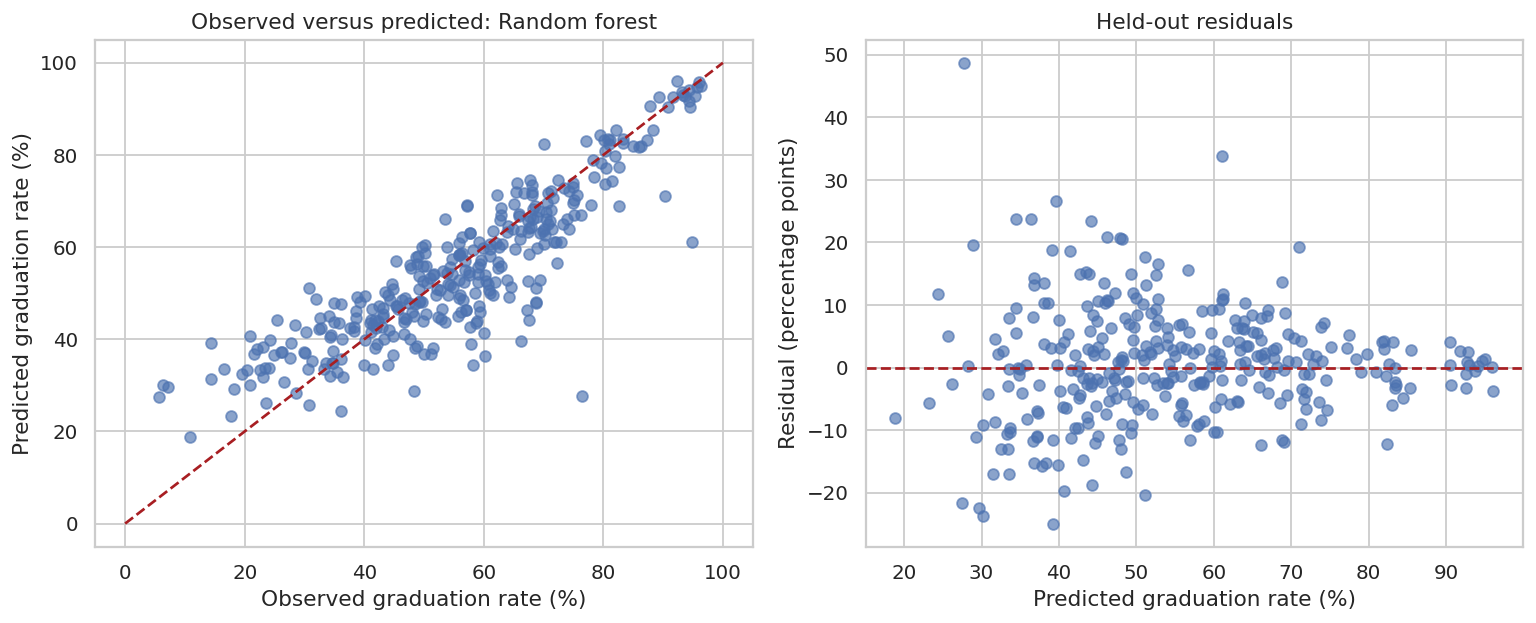

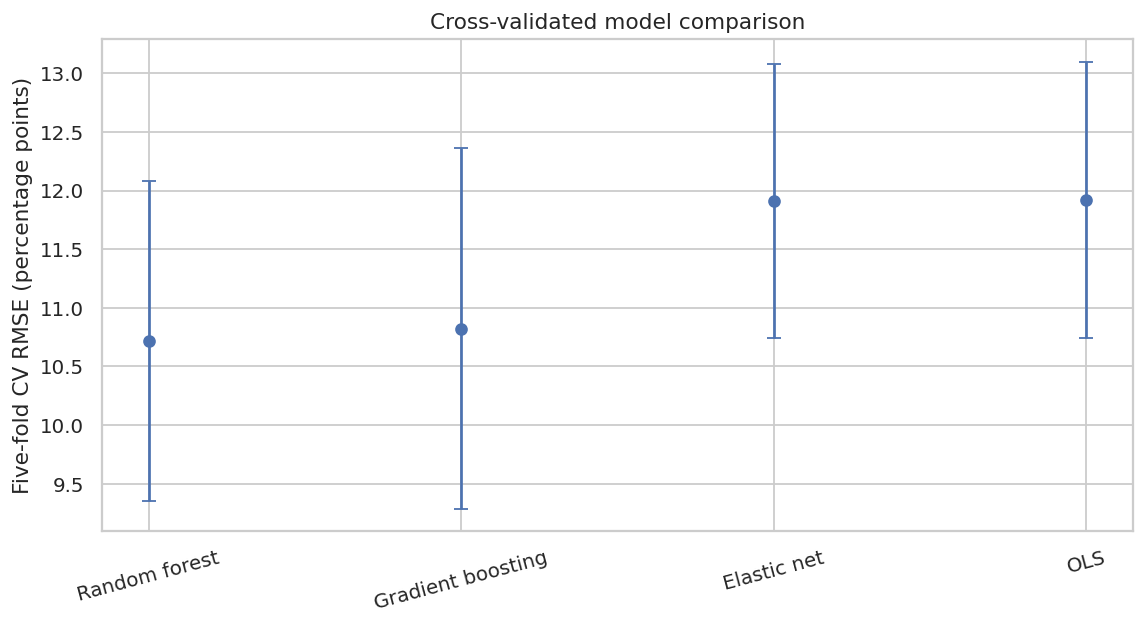

In [16]:
test_predictions = analytic.iloc[test_index][["UNITID", "INSTNM", "CONTROL_LABEL", "LOCALE4", "UGDS", TARGET]].copy()
for model_name, prediction in test_prediction_map.items():
    safe_name = re.sub(r"[^A-Za-z0-9]+", "_", model_name).strip("_").lower()
    test_predictions[f"PRED_{safe_name}"] = prediction
test_predictions["SELECTED_MODEL"] = best_model_name
test_predictions["PRED_SELECTED"] = best_test_prediction
test_predictions["RESIDUAL_SELECTED"] = test_predictions[TARGET] - test_predictions["PRED_SELECTED"]
save_table(test_predictions, "24_rq3_test_predictions.csv")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(y_test * 100, best_test_prediction * 100, alpha=0.65)
limits = [0, 100]
axes[0].plot(limits, limits, linestyle="--", color="#A81E22")
axes[0].set(xlabel="Observed graduation rate (%)", ylabel="Predicted graduation rate (%)", title=f"Observed versus predicted: {best_model_name}")
axes[1].scatter(best_test_prediction * 100, (y_test.values - best_test_prediction) * 100, alpha=0.65)
axes[1].axhline(0, linestyle="--", color="#A81E22")
axes[1].set(xlabel="Predicted graduation rate (%)", ylabel="Residual (percentage points)", title="Held-out residuals")
plt.tight_layout()
save_figure("06_rq3_test_performance.png")
plt.show()

plt.figure(figsize=(9, 5))
plot_cv = cv_summary.sort_values("mean_CV_RMSE")
plt.errorbar(plot_cv["model"], plot_cv["mean_CV_RMSE"] * 100, yerr=plot_cv["sd_CV_RMSE"] * 100, fmt="o", capsize=4)
plt.ylabel("Five-fold CV RMSE (percentage points)")
plt.title("Cross-validated model comparison")
plt.xticks(rotation=15)
plt.tight_layout()
save_figure("07_rq3_cv_model_comparison.png")
plt.show()


## 8. RQ4: Incremental predictive value of affordability

The model class selected only from training cross-validation is tuned for the full and reduced feature sets with the same folds and search budget. Fold-level errors use fixed tuned settings and identical validation observations. Final incremental $R^2$ and RMSE reduction are calculated on the untouched test set.

In [17]:
full_rq4_model, full_rq4_params, _ = fit_candidate(
    best_model_name, X_train, y_train, NUMERIC_FULL, CATEGORICAL_FULL, cv_splits)
reduced_rq4_model, reduced_rq4_params, _ = fit_candidate(
    best_model_name, X_train, y_train, NUMERIC_REDUCED, CATEGORICAL_REDUCED, cv_splits)

def paired_fold_errors(full_estimator, reduced_estimator):
    rows = []
    for fold, (fit_idx, validation_idx) in enumerate(cv_splits, start=1):
        full_fold = clone(full_estimator).fit(X_train.iloc[fit_idx], y_train.iloc[fit_idx])
        reduced_fold = clone(reduced_estimator).fit(X_train.iloc[fit_idx], y_train.iloc[fit_idx])
        y_validation = y_train.iloc[validation_idx]
        full_prediction = full_fold.predict(X_train.iloc[validation_idx])
        reduced_prediction = reduced_fold.predict(X_train.iloc[validation_idx])
        rows.append({
            "fold": fold,
            "full_MAE": mean_absolute_error(y_validation, full_prediction),
            "reduced_MAE": mean_absolute_error(y_validation, reduced_prediction),
            "full_RMSE": mean_squared_error(y_validation, full_prediction) ** 0.5,
            "reduced_RMSE": mean_squared_error(y_validation, reduced_prediction) ** 0.5,
            "full_R2": r2_score(y_validation, full_prediction),
            "reduced_R2": r2_score(y_validation, reduced_prediction),})
    result = pd.DataFrame(rows)
    result["MAE_difference_reduced_minus_full"] = result["reduced_MAE"] - result["full_MAE"]
    result["RMSE_difference_reduced_minus_full"] = result["reduced_RMSE"] - result["full_RMSE"]
    return result

rq4_folds = paired_fold_errors(full_rq4_model, reduced_rq4_model)

def paired_summary(values: pd.Series, metric: str) -> dict:
    n = len(values)
    mean_difference = values.mean()
    se = values.std(ddof=1) / np.sqrt(n)
    critical = stats.t.ppf(1 - ALPHA / 2, n - 1)
    t_result = stats.ttest_1samp(values, popmean=0)
    try:
        wilcoxon_p = stats.wilcoxon(values).pvalue
    except ValueError:
        wilcoxon_p = np.nan
    return {
        "metric": metric,
        "mean_reduced_minus_full": mean_difference,
        "ci_lower": mean_difference - critical * se,
        "ci_upper": mean_difference + critical * se,
        "paired_t_p": t_result.pvalue,
        "wilcoxon_p": wilcoxon_p,
        "folds": n,}

rq4_paired = pd.DataFrame([
    paired_summary(rq4_folds["MAE_difference_reduced_minus_full"], "MAE"),
    paired_summary(rq4_folds["RMSE_difference_reduced_minus_full"], "RMSE"),])

full_test_prediction = full_rq4_model.predict(X_test)
reduced_test_prediction = reduced_rq4_model.predict(X_test)
full_test_rmse = mean_squared_error(y_test, full_test_prediction) ** 0.5
reduced_test_rmse = mean_squared_error(y_test, reduced_test_prediction) ** 0.5
full_test_r2 = r2_score(y_test, full_test_prediction)
reduced_test_r2 = r2_score(y_test, reduced_test_prediction)
rq4_test = pd.DataFrame([{
    "selected_model_class": best_model_name,
    "full_test_MAE": mean_absolute_error(y_test, full_test_prediction),
    "reduced_test_MAE": mean_absolute_error(y_test, reduced_test_prediction),
    "full_test_RMSE": full_test_rmse,
    "reduced_test_RMSE": reduced_test_rmse,
    "RMSE_improvement_percent": 100 * (reduced_test_rmse - full_test_rmse) / reduced_test_rmse,
    "full_test_R2": full_test_r2,
    "reduced_test_R2": reduced_test_r2,
    "delta_R2": full_test_r2 - reduced_test_r2,}])

save_table(rq4_folds, "25_rq4_paired_fold_errors.csv")
save_table(rq4_paired, "26_rq4_paired_tests.csv")
save_table(rq4_test, "27_rq4_test_incremental_value.csv")
import joblib
joblib.dump(full_rq4_model, MODEL_DIR / "selected_full_model.joblib")
display(rq4_test.round(5))
display(rq4_paired.round(5))


,selected_model_class,full_test_MAE,reduced_test_MAE,full_test_RMSE,reduced_test_RMSE,RMSE_improvement_percent,full_test_R2,reduced_test_R2,delta_R2
0,Random forest,0.0672,0.08099,0.09131,0.11192,18.42,0.76769,0.65093,0.11675


,metric,mean_reduced_minus_full,ci_lower,ci_upper,paired_t_p,wilcoxon_p,folds
0,MAE,0.00770,0.00307,0.01234,0.00992,0.0625,5
1,RMSE,0.00992,0.00343,0.01641,0.01322,0.0625,5


## 9. Interpretation: permutation importance and partial dependence

Permutation importance is calculated on the untouched test set, so it measures model-wide predictive contribution rather than causation or an institution-specific explanation. Partial dependence is limited to the leading numeric features and remains associational.

,feature,importance_mean_RMSE_increase,importance_sd,feature_block
1,PCTPELL,0.05743,0.00409,Affordability
5,LOG_INEXPFTE,0.02873,0.00340,Institutional
4,ADM_RATE_SUPP,0.01957,0.00231,Institutional
6,LOG_AVGFACSAL,0.01307,0.00196,Institutional
0,LOG_NET_PRICE,0.00879,0.00200,Affordability
3,LOG_UGDS,0.00867,0.00161,Institutional
2,PCTFLOAN,0.00262,0.00101,Affordability
8,CONTROL_LABEL,0.00204,0.00057,Institutional
9,REGION_LABEL,0.00182,0.00061,Institutional
7,STUFACR,0.00158,0.00047,Institutional


,feature_block,summed_importance,features
0,Affordability,0.06885,3
1,Institutional,0.07636,8


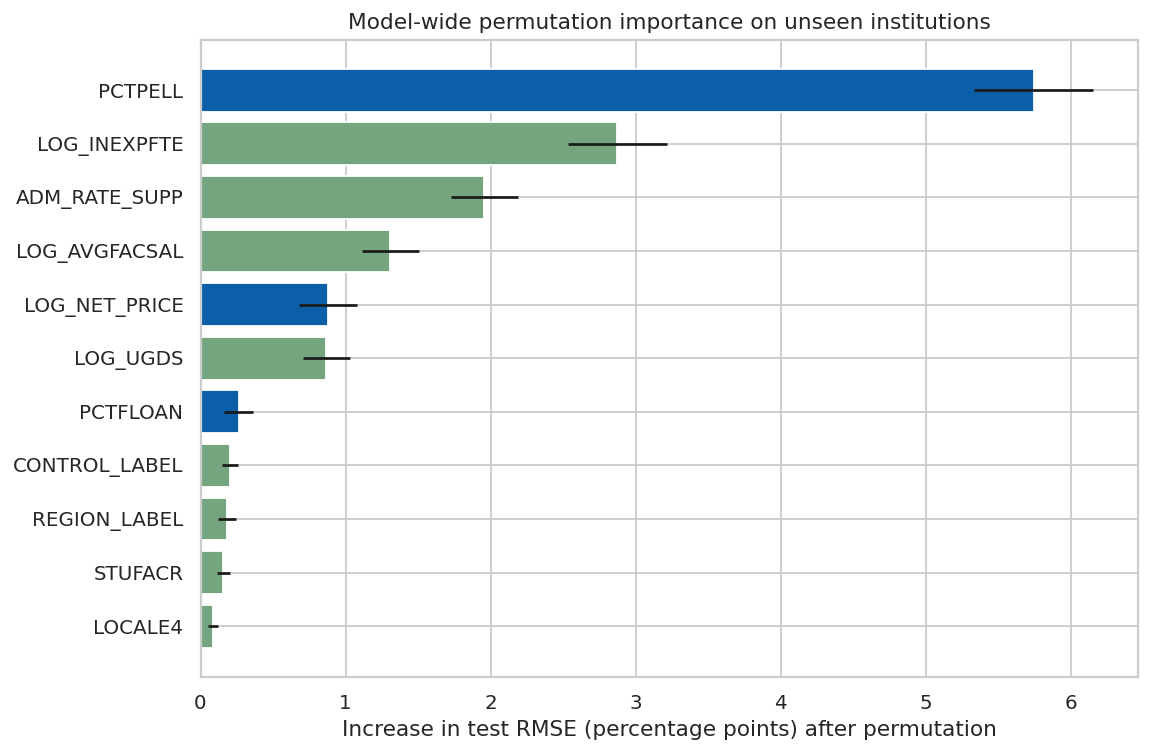

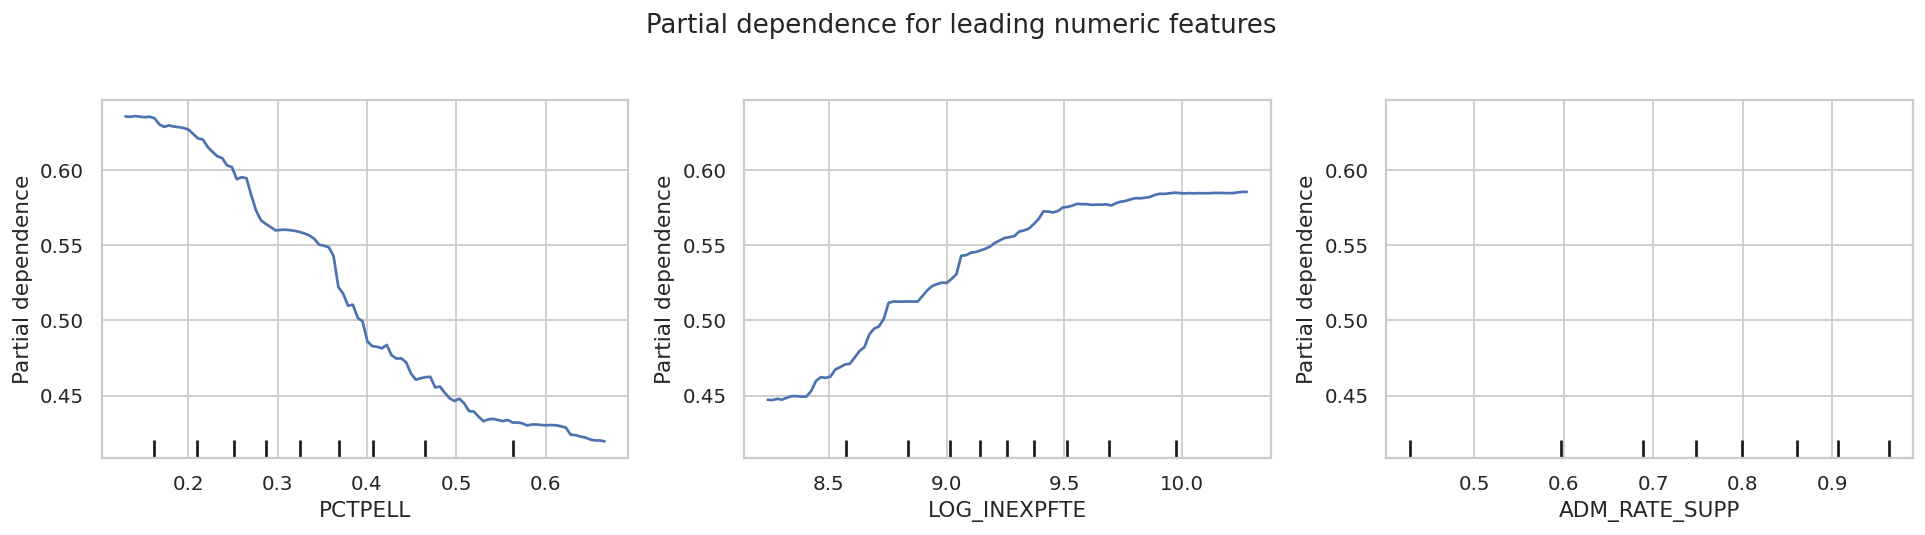

In [18]:
importance_result = permutation_importance(
    full_rq4_model, X_test, y_test, scoring="neg_root_mean_squared_error",
    n_repeats=30 if not QUICK_RUN else 8, random_state=RANDOM_STATE, n_jobs=N_JOBS,)
importance_table = pd.DataFrame({
    "feature": X_test.columns,
    "importance_mean_RMSE_increase": importance_result.importances_mean,
    "importance_sd": importance_result.importances_std,
}).sort_values("importance_mean_RMSE_increase", ascending=False)
importance_table["feature_block"] = np.where(
    importance_table["feature"].isin(AFFORDABILITY_FEATURES), "Affordability", "Institutional")
save_table(importance_table, "28_permutation_importance_test.csv")
importance_by_block = importance_table.groupby("feature_block", as_index=False).agg(
    summed_importance=("importance_mean_RMSE_increase", "sum"),
    features=("feature", "count"),)
save_table(importance_by_block, "28b_permutation_importance_by_block.csv")
display(importance_table.round(5))
display(importance_by_block.round(5))

plt.figure(figsize=(9, 6))
plot_importance = importance_table.sort_values("importance_mean_RMSE_increase")
colors = np.where(plot_importance["feature_block"].eq("Affordability"), "#0B5EA8", "#74A57F")
plt.barh(plot_importance["feature"], plot_importance["importance_mean_RMSE_increase"] * 100, xerr=plot_importance["importance_sd"] * 100, color=colors)
plt.xlabel("Increase in test RMSE (percentage points) after permutation")
plt.title("Model-wide permutation importance on unseen institutions")
plt.tight_layout()
save_figure("08_permutation_importance.png")
plt.show()

top_numeric = [feature for feature in importance_table["feature"] if feature in NUMERIC_FULL][:3]
if top_numeric:
    fig, ax = plt.subplots(1, len(top_numeric), figsize=(5 * len(top_numeric), 4), squeeze=False)
    PartialDependenceDisplay.from_estimator(full_rq4_model, X_train, features=top_numeric, ax=ax.ravel())
    plt.suptitle("Partial dependence for leading numeric features", y=1.03)
    plt.tight_layout()
    save_figure("09_partial_dependence.png")
    plt.show()


## 10. CV+ conformal prediction intervals

Each fold model predicts the untouched test institutions and supplies absolute validation residuals. The resulting CV+ intervals use the same definition for linear and tree-based models. Coverage and average width are reported only on the untouched test set.

In [19]:
def cv_plus_intervals(estimator, X_train, y_train, X_new, folds, alpha=0.05):
    lower_candidates = []
    upper_candidates = []
    fold_models = []
    for fit_idx, validation_idx in folds:
        fold_model = clone(estimator).fit(X_train.iloc[fit_idx], y_train.iloc[fit_idx])
        validation_prediction = fold_model.predict(X_train.iloc[validation_idx])
        residual_scores = np.abs(y_train.iloc[validation_idx].to_numpy() - validation_prediction)
        new_prediction = fold_model.predict(X_new)
        lower_candidates.append(new_prediction[:, None] - residual_scores[None, :])
        upper_candidates.append(new_prediction[:, None] + residual_scores[None, :])
        fold_models.append(fold_model)
    lower_matrix = np.concatenate(lower_candidates, axis=1)
    upper_matrix = np.concatenate(upper_candidates, axis=1)
    n_scores = lower_matrix.shape[1]
    lower_q = max(0, math.floor(alpha * (n_scores + 1)) / n_scores)
    upper_q = min(1, math.ceil((1 - alpha) * (n_scores + 1)) / n_scores)
    try:
        lower = np.quantile(lower_matrix, lower_q, axis=1, method="lower")
        upper = np.quantile(upper_matrix, upper_q, axis=1, method="higher")
    except TypeError:
        lower = np.quantile(lower_matrix, lower_q, axis=1, interpolation="lower")
        upper = np.quantile(upper_matrix, upper_q, axis=1, interpolation="higher")
    center = np.mean(np.column_stack([model.predict(X_new) for model in fold_models]), axis=1)
    return center, np.clip(lower, 0, 1), np.clip(upper, 0, 1), fold_models

cvplus_center, cvplus_lower, cvplus_upper, cvplus_models = cv_plus_intervals(
    full_rq4_model, X_train, y_train, X_test, cv_splits, alpha=ALPHA)
coverage = np.mean((y_test.to_numpy() >= cvplus_lower) & (y_test.to_numpy() <= cvplus_upper))
average_width = np.mean(cvplus_upper - cvplus_lower)
interval_results = pd.DataFrame([{
    "method": "CV+ conformal prediction",
    "nominal_coverage": 1 - ALPHA,
    "empirical_test_coverage": coverage,
    "average_interval_width": average_width,
    "test_n": len(y_test),}])

test_predictions["CVPLUS_CENTER"] = cvplus_center
test_predictions["PI95_LOWER"] = cvplus_lower
test_predictions["PI95_UPPER"] = cvplus_upper
test_predictions["PI95_COVERED"] = (
    (test_predictions[TARGET] >= test_predictions["PI95_LOWER"])
    & (test_predictions[TARGET] <= test_predictions["PI95_UPPER"]))
save_table(interval_results, "29_cvplus_interval_performance.csv")
save_table(test_predictions, "24_rq3_test_predictions.csv")
display(interval_results.round(5))


,method,nominal_coverage,empirical_test_coverage,average_interval_width,test_n
0,CV+ conformal prediction,0.95,0.97904,0.44042,334


## 11. Subgroup error and responsible-use audit

Performance is reported for control and locale groups with at least 20 test institutions. Small groups remain visible in the sample-count file but do not receive unstable error estimates. Mean residuals detect systematic overprediction or underprediction. These comparisons are model audits, not measures of group quality.

In [20]:
def subgroup_metrics(frame: pd.DataFrame, group_column: str) -> pd.DataFrame:
    rows = []
    for level, group in frame.groupby(group_column, dropna=False):
        row = {"group_variable": group_column, "group": level, "n": len(group)}
        if len(group) >= MIN_SUBGROUP_N:
            row.update({
                "MAE": mean_absolute_error(group[TARGET], group["PRED_SELECTED"]),
                "RMSE": mean_squared_error(group[TARGET], group["PRED_SELECTED"]) ** 0.5,
                "R2": r2_score(group[TARGET], group["PRED_SELECTED"]) if len(group) > 1 else np.nan,
                "mean_residual_observed_minus_predicted": group["RESIDUAL_SELECTED"].mean(),
                "interval_coverage": group["PI95_COVERED"].mean(),
                "reported": True,})
        else:
            row.update({"MAE": np.nan, "RMSE": np.nan, "R2": np.nan, "mean_residual_observed_minus_predicted": np.nan, "interval_coverage": np.nan, "reported": False})
        rows.append(row)
    return pd.DataFrame(rows)

subgroup_table = pd.concat([
    subgroup_metrics(test_predictions, "CONTROL_LABEL"),
    subgroup_metrics(test_predictions, "LOCALE4"),
], ignore_index=True)
save_table(subgroup_table, "30_subgroup_performance.csv")
display(subgroup_table.round(5))


,group_variable,group,n,MAE,RMSE,R2,mean_residual_observed_minus_predicted,interval_coverage,reported
0,CONTROL_LABEL,Private for-profit,15,NaN,NaN,NaN,NaN,NaN,False
1,CONTROL_LABEL,Private nonprofit,209,0.06639,0.09260,0.75209,0.01197,0.97608,True
2,CONTROL_LABEL,Public,110,0.06239,0.07948,0.79059,-0.00528,1.00000,True
3,LOCALE4,City,158,0.07037,0.09008,0.78308,0.00568,0.98101,True
4,LOCALE4,Rural,35,0.08292,0.11938,0.54712,-0.00155,0.94286,True
5,LOCALE4,Suburb,79,0.06187,0.09059,0.79559,0.01083,0.97468,True
6,LOCALE4,Town,62,0.05701,0.07570,0.75297,0.00584,1.00000,True


## 12. Predictive sensitivity analyses

The primary selected model is re-estimated under three planned checks: complete predictor cases, training-derived 1st/99th-percentile clipping, and the alternative unpooled six-year outcome. Each check preserves the frozen institution split whenever the needed outcome is available.

In [21]:
sensitivity_rows = []

complete_train_mask = X_train[MODEL_COLUMNS].notna().all(axis=1)
complete_test_mask = X_test[MODEL_COLUMNS].notna().all(axis=1)
if complete_train_mask.sum() >= MIN_ANALYTIC_N * (1 - TEST_SIZE) and complete_test_mask.sum() >= 30:
    complete_model = clone(full_rq4_model).fit(X_train.loc[complete_train_mask], y_train.loc[complete_train_mask])
    complete_prediction = complete_model.predict(X_test.loc[complete_test_mask])
    sensitivity_rows.append({
        "analysis": "Complete predictor cases", "train_n": int(complete_train_mask.sum()), "test_n": int(complete_test_mask.sum()),
        **{k: v for k, v in metric_row("complete", y_test.loc[complete_test_mask], complete_prediction).items() if k != "model"},})

X_train_w = X_train.copy()
X_test_w = X_test.copy()
for column in NUMERIC_FULL:
    lower, upper = X_train[column].quantile([0.01, 0.99])
    X_train_w[column] = X_train_w[column].clip(lower, upper)
    X_test_w[column] = X_test_w[column].clip(lower, upper)
winsor_model = clone(full_rq4_model).fit(X_train_w, y_train)
winsor_prediction = winsor_model.predict(X_test_w)
sensitivity_rows.append({
    "analysis": "Training-derived 1st/99th percentile clipping", "train_n": len(y_train), "test_n": len(y_test),
    **{k: v for k, v in metric_row("winsorized", y_test, winsor_prediction).items() if k != "model"},})

alt_train_rows = analytic.iloc[train_index]["C150_4"].notna().to_numpy()
alt_test_rows = analytic.iloc[test_index]["C150_4"].notna().to_numpy()
if alt_train_rows.sum() >= MIN_ANALYTIC_N * (1 - TEST_SIZE) and alt_test_rows.sum() >= 30:
    y_train_alt = analytic.iloc[train_index].loc[analytic.iloc[train_index]["C150_4"].notna(), "C150_4"]
    y_test_alt = analytic.iloc[test_index].loc[analytic.iloc[test_index]["C150_4"].notna(), "C150_4"]
    X_train_alt = X_train.loc[y_train_alt.index]
    X_test_alt = X_test.loc[y_test_alt.index]
    alt_model = clone(full_rq4_model).fit(X_train_alt, y_train_alt)
    alt_prediction = alt_model.predict(X_test_alt)
    sensitivity_rows.append({
        "analysis": "Alternative outcome C150_4", "train_n": len(y_train_alt), "test_n": len(y_test_alt),
        **{k: v for k, v in metric_row("C150_4", y_test_alt, alt_prediction).items() if k != "model"},})

sensitivity_table = pd.DataFrame(sensitivity_rows)
save_table(sensitivity_table, "31_predictive_sensitivity.csv")
display(sensitivity_table.round(5))


,analysis,train_n,test_n,MAE,RMSE,R2,observed_predicted_r,observed_predicted_r_p_value
0,Complete predictor cases,1138,287,0.06241,0.08685,0.73758,0.86219,0.0
1,Training-derived 1st/99th percentile clipping,1335,334,0.06688,0.09124,0.76803,0.87719,0.0
2,Alternative outcome C150_4,1332,334,0.07131,0.09433,0.75573,0.86992,0.0


## 13. Dashboard-ready benchmarking export

The dashboard file contains only out-of-sample test institutions. Its expected rates and residuals were not fitted on those institutions, and its intervals use CV+ conformal prediction. Peers first match control, locale, and enrollment quartile. When fewer than 20 peers are available, locale is relaxed and the broader rule is recorded.

In [22]:
analytic_peer = analytic[["UNITID", "INSTNM", "CONTROL_LABEL", "LOCALE4", "UGDS", TARGET]].copy()
analytic_peer["ENROLLMENT_QUARTILE"] = pd.qcut(
    analytic_peer["UGDS"].rank(method="first"), 4, labels=["Q1 smallest", "Q2", "Q3", "Q4 largest"]
).astype(str)
quartile_lookup = analytic_peer.set_index("UNITID")["ENROLLMENT_QUARTILE"]

dashboard = test_predictions.copy()
dashboard["ENROLLMENT_QUARTILE"] = dashboard["UNITID"].map(quartile_lookup)
dashboard["MODEL_EXPECTED"] = dashboard["CVPLUS_CENTER"]
dashboard["OBSERVED_MINUS_EXPECTED"] = dashboard[TARGET] - dashboard["MODEL_EXPECTED"]
dashboard["PREDICTION_STATUS"] = "Untouched holdout institution"
dashboard["MODEL_VERSION"] = "QM640-v1.0"
dashboard["DATA_RELEASE_DATE"] = "2026-06-10"
dashboard["RETRAIN_BY"] = "2027-06-10 or immediately after a material source/schema change"
dashboard["INTENDED_USE"] = "Contextual benchmarking; association, not causation; not a ranking or individual forecast"

peer_rows = []
for _, row in dashboard.iterrows():
    peer_mask = (
        analytic_peer["CONTROL_LABEL"].eq(row["CONTROL_LABEL"])
        & analytic_peer["LOCALE4"].eq(row["LOCALE4"])
        & analytic_peer["ENROLLMENT_QUARTILE"].eq(row["ENROLLMENT_QUARTILE"]))
    rule = "control + locale + enrollment quartile"
    if peer_mask.sum() < MIN_SUBGROUP_N:
        peer_mask = (
            analytic_peer["CONTROL_LABEL"].eq(row["CONTROL_LABEL"])
            & analytic_peer["ENROLLMENT_QUARTILE"].eq(row["ENROLLMENT_QUARTILE"]))
        rule = "control + enrollment quartile (locale relaxed)"
    if peer_mask.sum() < MIN_SUBGROUP_N:
        peer_mask = analytic_peer["CONTROL_LABEL"].eq(row["CONTROL_LABEL"])
        rule = "control only"
    peers = analytic_peer.loc[peer_mask]
    peer_rows.append({
        "UNITID": row["UNITID"], "PEER_RULE": rule, "PEER_N": len(peers),
        "PEER_OBSERVED_MEAN": peers[TARGET].mean(), "PEER_OBSERVED_MEDIAN": peers[TARGET].median(),})
dashboard = dashboard.merge(pd.DataFrame(peer_rows), on="UNITID", how="left")

dashboard_columns = [
    "UNITID", "INSTNM", "CONTROL_LABEL", "LOCALE4", "ENROLLMENT_QUARTILE",
    TARGET, "MODEL_EXPECTED", "OBSERVED_MINUS_EXPECTED", "PI95_LOWER", "PI95_UPPER",
    "PEER_RULE", "PEER_N", "PEER_OBSERVED_MEAN", "PEER_OBSERVED_MEDIAN",
    "SELECTED_MODEL", "MODEL_VERSION", "DATA_RELEASE_DATE", "RETRAIN_BY",
    "PREDICTION_STATUS", "INTENDED_USE",]
dashboard = dashboard[dashboard_columns].sort_values("INSTNM")
save_table(dashboard, "32_dashboard_holdout_benchmarks.csv")
display(dashboard.head(10).round(4))


,UNITID,INSTNM,CONTROL_LABEL,LOCALE4,ENROLLMENT_QUARTILE,C150_4_POOLED_SUPP,MODEL_EXPECTED,OBSERVED_MINUS_EXPECTED,PI95_LOWER,PI95_UPPER,PEER_RULE,PEER_N,PEER_OBSERVED_MEAN,PEER_OBSERVED_MEDIAN,SELECTED_MODEL,MODEL_VERSION,DATA_RELEASE_DATE,RETRAIN_BY,PREDICTION_STATUS,INTENDED_USE
45,138558,Abraham Baldwin Agricultural College,Public,Town,Q3,0.3251,0.4332,-0.1081,0.2086,0.6599,control + locale + enrollment quartile,59,0.4712,0.4599,Random forest,QM640-v1.0,2026-06-10,2027-06-10 or immediately after a material sou...,Untouched holdout institution,"Contextual benchmarking; association, not caus..."
219,172866,Academy College,Private for-profit,City,Q1 smallest,0.4839,0.4592,0.0247,0.2343,0.6858,control + locale + enrollment quartile,31,0.3501,0.3240,Random forest,QM640-v1.0,2026-06-10,2027-06-10 or immediately after a material sou...,Untouched holdout institution,"Contextual benchmarking; association, not caus..."
121,188429,Adelphi University,Private nonprofit,Suburb,Q4 largest,0.6800,0.7147,-0.0347,0.4942,0.9378,control + locale + enrollment quartile,25,0.7034,0.7046,Random forest,QM640-v1.0,2026-06-10,2027-06-10 or immediately after a material sou...,Untouched holdout institution,"Contextual benchmarking; association, not caus..."
300,100724,Alabama State University,Public,City,Q3,0.3026,0.4067,-0.1041,0.1862,0.6302,control + locale + enrollment quartile,54,0.4284,0.4151,Random forest,QM640-v1.0,2026-06-10,2027-06-10 or immediately after a material sou...,Untouched holdout institution,"Contextual benchmarking; association, not caus..."
318,188526,Albany College of Pharmacy and Health Sciences,Private nonprofit,City,Q1 smallest,0.6817,0.6649,0.0168,0.4427,0.8890,control + locale + enrollment quartile,162,0.4650,0.4849,Random forest,QM640-v1.0,2026-06-10,2027-06-10 or immediately after a material sou...,Untouched holdout institution,"Contextual benchmarking; association, not caus..."
140,128498,Albertus Magnus College,Private nonprofit,City,Q2,0.4930,0.4812,0.0118,0.2601,0.7092,control + locale + enrollment quartile,148,0.5685,0.5730,Random forest,QM640-v1.0,2026-06-10,2027-06-10 or immediately after a material sou...,Untouched holdout institution,"Contextual benchmarking; association, not caus..."
280,168546,Albion College,Private nonprofit,Town,Q2,0.5913,0.4656,0.1257,0.2487,0.6954,control + locale + enrollment quartile,83,0.5555,0.5446,Random forest,QM640-v1.0,2026-06-10,2027-06-10 or immediately after a material sou...,Untouched holdout institution,"Contextual benchmarking; association, not caus..."
130,132842,Albizu University-Miami,Private nonprofit,City,Q1 smallest,0.4839,0.2987,0.1852,0.0744,0.5283,control + locale + enrollment quartile,162,0.4650,0.4849,Random forest,QM640-v1.0,2026-06-10,2027-06-10 or immediately after a material sou...,Untouched holdout institution,"Contextual benchmarking; association, not caus..."
94,210571,Albright College,Private nonprofit,City,Q2,0.4687,0.4799,-0.0112,0.2593,0.7038,control + locale + enrollment quartile,148,0.5685,0.5730,Random forest,QM640-v1.0,2026-06-10,2027-06-10 or immediately after a material sou...,Untouched holdout institution,"Contextual benchmarking; association, not caus..."
106,175342,Alcorn State University,Public,Rural,Q3,0.5120,0.3782,0.1338,0.1566,0.6002,control + enrollment quartile (locale relaxed),153,0.4542,0.4389,Random forest,QM640-v1.0,2026-06-10,2027-06-10 or immediately after a material sou...,Untouched holdout institution,"Contextual benchmarking; association, not caus..."


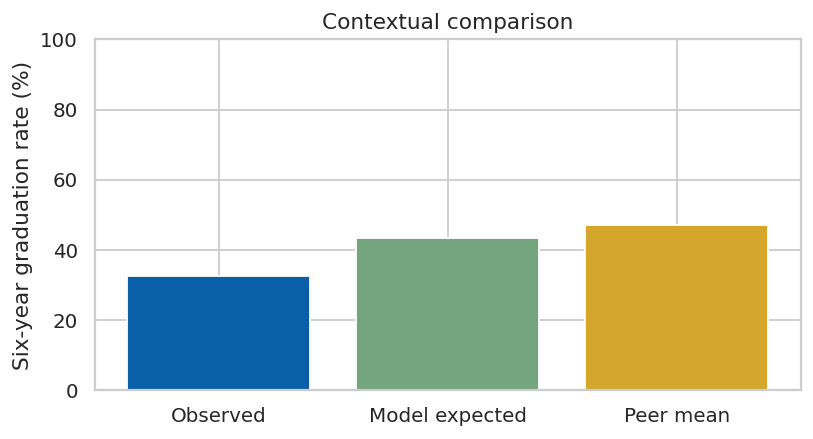

In [23]:
try:
    import ipywidgets as widgets

    options = [(f"{name} ({int(unitid)})", int(unitid)) for name, unitid in dashboard[["INSTNM", "UNITID"]].itertuples(index=False, name=None)]
    selector = widgets.Dropdown(options=options, description="Institution:", layout=widgets.Layout(width="80%"))
    dashboard_output = widgets.Output()

    def render_dashboard(change=None):
        with dashboard_output:
            dashboard_output.clear_output(wait=True)
            row = dashboard.loc[dashboard["UNITID"].eq(selector.value)].iloc[0]
            display(HTML(
                f"<h3>{row['INSTNM']}</h3>"
                f"<b>Observed:</b> {100*row[TARGET]:.1f}% &nbsp; "
                f"<b>Model expected:</b> {100*row['MODEL_EXPECTED']:.1f}% &nbsp; "
                f"<b>Observed minus expected:</b> {100*row['OBSERVED_MINUS_EXPECTED']:.1f} percentage points<br>"
                f"<b>95% prediction interval:</b> {100*row['PI95_LOWER']:.1f}% to {100*row['PI95_UPPER']:.1f}%<br>"
                f"<b>Peer definition:</b> {row['PEER_RULE']} (N={int(row['PEER_N'])})<br>"
                f"<i>Association, not causation. This is not a consumer ranking or an individual-student forecast.</i>"))
            values = [100 * row[TARGET], 100 * row["MODEL_EXPECTED"], 100 * row["PEER_OBSERVED_MEAN"]]
            plt.figure(figsize=(7, 3.5))
            plt.bar(["Observed", "Model expected", "Peer mean"], values, color=["#0B5EA8", "#74A57F", "#D4A72C"])
            plt.ylabel("Six-year graduation rate (%)")
            plt.ylim(0, max(100, max(values) + 10))
            plt.title("Contextual comparison")
            plt.show()

    selector.observe(render_dashboard, names="value")
    display(selector, dashboard_output)
    render_dashboard()
except Exception as exc:
    print("Interactive display unavailable; the dashboard CSV was still created.", exc)


## 14. Automated results summary, integrity checks, and download

The final cells combine the principal findings without making causal claims, verify that the expected files exist, and package the processed data, tables, figures, models metadata, and source manifest.

In [24]:
rq1_p = rq1_block.loc[0, "p_value"]
rq2_control_p = rq2_global.loc[rq2_global["factor"] == "CONTROL_LABEL", "p_value"].iloc[0]
rq2_locale_p = rq2_global.loc[rq2_global["factor"] == "LOCALE4", "p_value"].iloc[0]
rq4_row = rq4_test.iloc[0]
selected_cv_row = cv_summary.loc[cv_summary["model"].eq(best_model_name)].iloc[0]
cv_rmse_coefficient_of_variation = selected_cv_row["sd_CV_RMSE"] / selected_cv_row["mean_CV_RMSE"]
reported_subgroups = subgroup_table.loc[subgroup_table["reported"]].copy()
subgroup_rmse_limit = 1.5 * best_test_row["RMSE"]
subgroup_rmse_rule_pass = bool((reported_subgroups["RMSE"] <= subgroup_rmse_limit).all())

summary_lines = [
    "# QM 640 Capstone Automated Analysis Summary",
    "",
    f"- Analytic institutions: {len(analytic):,} (minimum planned: {MIN_ANALYTIC_N}).",
    f"- Frozen split: {len(y_train):,} training and {len(y_test):,} untouched test institutions.",
    f"- RQ1 joint affordability block: HC3 F={rq1_block.loc[0, 'F']:.3f}, p={rq1_p:.4g}, partial R²={rq1_block.loc[0, 'partial_r2']:.4f}.",
    f"- RQ2 control global test: p={rq2_control_p:.4g}; locale global test: p={rq2_locale_p:.4g}.",
    f"- RQ3 selected from training CV: {best_model_name}; test MAE={best_test_row['MAE']:.4f}, RMSE={best_test_row['RMSE']:.4f}, R²={best_test_row['R2']:.4f}.",
    f"- RQ3 RMSE change from the mean baseline: {rmse_reduction:.1f}% reduction.",
    f"- Selected-model CV RMSE coefficient of variation: {cv_rmse_coefficient_of_variation:.3f}.",
    f"- Subgroup RMSE rule: {subgroup_rmse_rule_pass}; limit={subgroup_rmse_limit:.4f}.",
    f"- RQ4 affordability increment: ΔR²={rq4_row['delta_R2']:.4f}; RMSE improvement={rq4_row['RMSE_improvement_percent']:.1f}%.",
    f"- CV+ interval coverage: {coverage:.3f}; average width={average_width:.3f} on the 0–1 outcome scale.",
    f"- RQ1 influence diagnostic: maximum Cook's distance={diagnostics.loc[0, 'max_cooks_d']:.5f}; cases above 4/N={int(diagnostics.loc[0, 'cooks_d_over_4_over_n'])}.",
    "",
    "These results describe adjusted associations and out-of-sample prediction. They do not establish causal effects, rank colleges, or estimate an individual student's chance of graduating.",]
summary_path = ROOT / "reports" / "automated_results_summary.md"
summary_path.write_text("\n".join(summary_lines), encoding="utf-8")
display(Markdown("\n".join(summary_lines)))

required_outputs = [
    PROCESSED_DIR / "college_graduation_analysis.csv",
    TABLE_DIR / "10_rq1_affordability_block_test.csv",
    TABLE_DIR / "15_rq2_global_tests.csv",
    TABLE_DIR / "21_rq3_test_metrics.csv",
    TABLE_DIR / "27_rq4_test_incremental_value.csv",
    TABLE_DIR / "29_cvplus_interval_performance.csv",
    TABLE_DIR / "30_subgroup_performance.csv",
    TABLE_DIR / "32_dashboard_holdout_benchmarks.csv",
    FIGURE_DIR / "06_rq3_test_performance.png",
    RAW_DIR / "source_manifest.json",]
missing_outputs = [str(path) for path in required_outputs if not path.exists()]
assert not missing_outputs, f"Missing expected outputs: {missing_outputs}"
print(f"Integrity check passed for {len(required_outputs)} required outputs.")


Integrity check passed for 10 required outputs.


# QM 640 Capstone Automated Analysis Summary

- Analytic institutions: 1,669 (minimum planned: 368).
- Frozen split: 1,335 training and 334 untouched test institutions.
- RQ1 joint affordability block: HC3 F=59.804, p=1.081e-36, partial R²=0.1600.
- RQ2 control global test: p=8.932e-17; locale global test: p=0.2248.
- RQ3 selected from training CV: Random forest; test MAE=0.0672, RMSE=0.0913, R²=0.7677.
- RQ3 RMSE change from the mean baseline: 51.8% reduction.
- Selected-model CV RMSE coefficient of variation: 0.127.
- Subgroup RMSE rule: True; limit=0.1370.
- RQ4 affordability increment: ΔR²=0.1168; RMSE improvement=18.4%.
- CV+ interval coverage: 0.979; average width=0.440 on the 0–1 outcome scale.
- RQ1 influence diagnostic: maximum Cook's distance=0.39268; cases above 4/N=118.

These results describe adjusted associations and out-of-sample prediction. They do not establish causal effects, rank colleges, or estimate an individual student's chance of graduating.

In [25]:
ARCHIVE_PATH = ROOT / "QM640_Capstone_Outputs.zip"
with zipfile.ZipFile(ARCHIVE_PATH, "w", compression=zipfile.ZIP_DEFLATED) as archive:
    for folder in [PROCESSED_DIR, TABLE_DIR, FIGURE_DIR, MODEL_DIR]:
        for path in folder.rglob("*"):
            if path.is_file():
                archive.write(path, path.relative_to(ROOT))
    for path in [RAW_DIR / "source_manifest.json", ROOT / "requirements_locked.txt", summary_path]:
        if path.exists():
            archive.write(path, path.relative_to(ROOT))
print(f"Created archive: {ARCHIVE_PATH} ({ARCHIVE_PATH.stat().st_size:,} bytes)")
try:
    from google.colab import files
    files.download(str(ARCHIVE_PATH))
except ImportError:
    print("Outside Colab: download the ZIP from", ARCHIVE_PATH)


Created archive: /workspace/scratch/0a241a8fa247/tmp/capstone_full_run_9pMX09/QM640_Capstone_Outputs.zip (10,787,617 bytes)
Outside Colab: download the ZIP from /workspace/scratch/0a241a8fa247/tmp/capstone_full_run_9pMX09/QM640_Capstone_Outputs.zip
